# Stephenson + COMBAT integration: patient-level representations end-to-end

This is a self-contained walkthrough of running [`patpy`](https://github.com/lueckenlab/patpy) on the harmonised **Stephenson + COMBAT** COVID-19 cohort. It builds seven sample-level representations of the same 251 donors, packs them all into one `meta_adata`, and benchmarks them with patpy metrics: KNN scoring (clinical info retention + batch mixing), diffusion-pseudotime correlation with severity, leiden clustering ARI against `Site` and `Status`, gene + cell-type-proportion correlation with pseudotime, and per-cluster marker genes.

| `meta_adata` slot | method | role |
|---|---|---|
| `.X` / `obsm["X_pseudobulk_lognorm"]` | mean pseudobulk on log-normalised counts (`patpy.tl.Pseudobulk`) | baseline |
| `obsm["X_pseudobulk_scanvi"]`         | mean pseudobulk on the dataset-shipped scANVI embedding | latent baseline |
| `obsm["X_composition_clr"]`           | `patpy.tl.CellGroupComposition(apply_clr=True)` | SETA-style composition |
| `obsm["X_gloscope_py"]`               | `patpy.tl.GloScope_py(use_gpu=True)` (RAPIDS cuML on GPU) | symmetric-KL distance, MDS-embedded |
| `obsm["X_sampleclr_ssl"]`             | `patpy.tl.SampleCLR.prepare_anndata(pretrain=True)` | self-supervised (lueckenlab/SampleCLR) |
| `obsm["X_sampleclr_ft"]`              | `.fine_tune` on `severity_idx` | same model, supervised head |
| `obsm["X_pascient"]`                  | `patpy.tl.PaSCient` trained from scratch | hierarchical encoder |

Outputs (under `data/stephenson_combat/`):
- `stephenson_combat_meta_adata.h5ad` — final AnnData with every embedding, pairwise distance matrix, per-rep neighbor graph + UMAP, leiden clusters, pseudotime, and benchmark tables.
- `models/sampleclr_{ssl,ft}_state.pt`, `models/pascient_state.pt` — model checkpoints.
- `benchmark_knn_scores.csv`, `benchmark_trajectory_correlation.csv`, `benchmark_clustering_ari.csv`.


In [1]:
# One-time installs (uncomment if missing). Notebook expects the most
# recent patpy and sampleclr available on GitHub.
# %pip install -U "git+https://github.com/lueckenlab/patpy.git@main"
# %pip install -U "git+https://github.com/lueckenlab/SampleCLR.git@main"
# %pip install git+https://github.com/genentech/pascient.git@main
# %pip install "cupy-cuda12x" "cuml-cu12"   # GPU GloScope_py only


In [2]:
import gc
import json
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch

import patpy
import sampleclr
from sampleclr.utils import get_sample_representations_from_adata

print("patpy     :", patpy.__version__)
print("sampleclr :", sampleclr.__version__)
print("scanpy    :", sc.__version__)
print("anndata   :", ad.__version__)
print("torch     :", torch.__version__, "  cuda?", torch.cuda.is_available())

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path("/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/docs/notebooks/data/stephenson_combat")
MODELS_DIR = DATA_DIR / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR   :", DATA_DIR)

# ---- Notebook-wide figure style -------------------------------------------
from adjustText import adjust_text  # noqa: E402

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
})

# Severity levels share one colour map across every figure (UMAPs, boxplots,
# head-weight panels). "nan" (unknown severity) is rendered light-grey only
# where it has to appear.
SEVERITY_ORDER = ["healthy", "mild", "moderate", "severe", "critical"]
SEVERITY_PALETTE = {
    "healthy": "lightblue",
    "mild": "royalblue",
    "moderate": "orange",
    "severe": "salmon",
    "critical": "darkred",
}


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


patpy     : 0.16.5
sampleclr : 0.1.0
scanpy    : 1.12
anndata   : 0.12.10
torch     : 2.10.0+cu128   cuda? True


/localscratch/vladimir.shitov/ipykernel_1036264/1991648296.py:19: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy    :", sc.__version__)
/localscratch/vladimir.shitov/ipykernel_1036264/1991648296.py:20: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("anndata   :", ad.__version__)


DATA_DIR   : /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/docs/notebooks/data/stephenson_combat


## 1. Load the integrated COVID-19 dataset


In [3]:
adata, info = patpy.datasets.combat_stephenson(return_dataset_info=True)
adata.obsm["X_umap"] = adata.obsm["X_umap_scANVI_dataset"]
print(adata)
print("layers:", list(adata.layers))
print("sample_key   :", info.sample_key, " cell_type_key:", info.cell_type_key)
print("n_samples    :", adata.obs[info.sample_key].nunique())


AnnData object with n_obs × n_vars = 1399435 × 1856
    obs: 'Site', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'split', 'cell_coarse_aligned', 'Status', 'severity_ord', 'severity_idx', 'outcome_bin', 'dataset', 'sample_id', 'Status_encoded', 'leiden'
    uns: 'Site_colors', 'X_scVI_neighbors', 'X_umap_scANVI_dataset', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'cell_coarse_aligned_colors', 'dataset_colors', 'leiden', 'leiden_colors', 'neighbors', 'scANVI_neighbors_dataset', 'severity_ord_colors', 'umap'
    obsm: 'X_pca', 'X_scANVI', 'X_scANVI_batch', 'X_scANVI_dataset', 'X_scANVI_sample', 'X_scVI', 'X_scVI_batch',

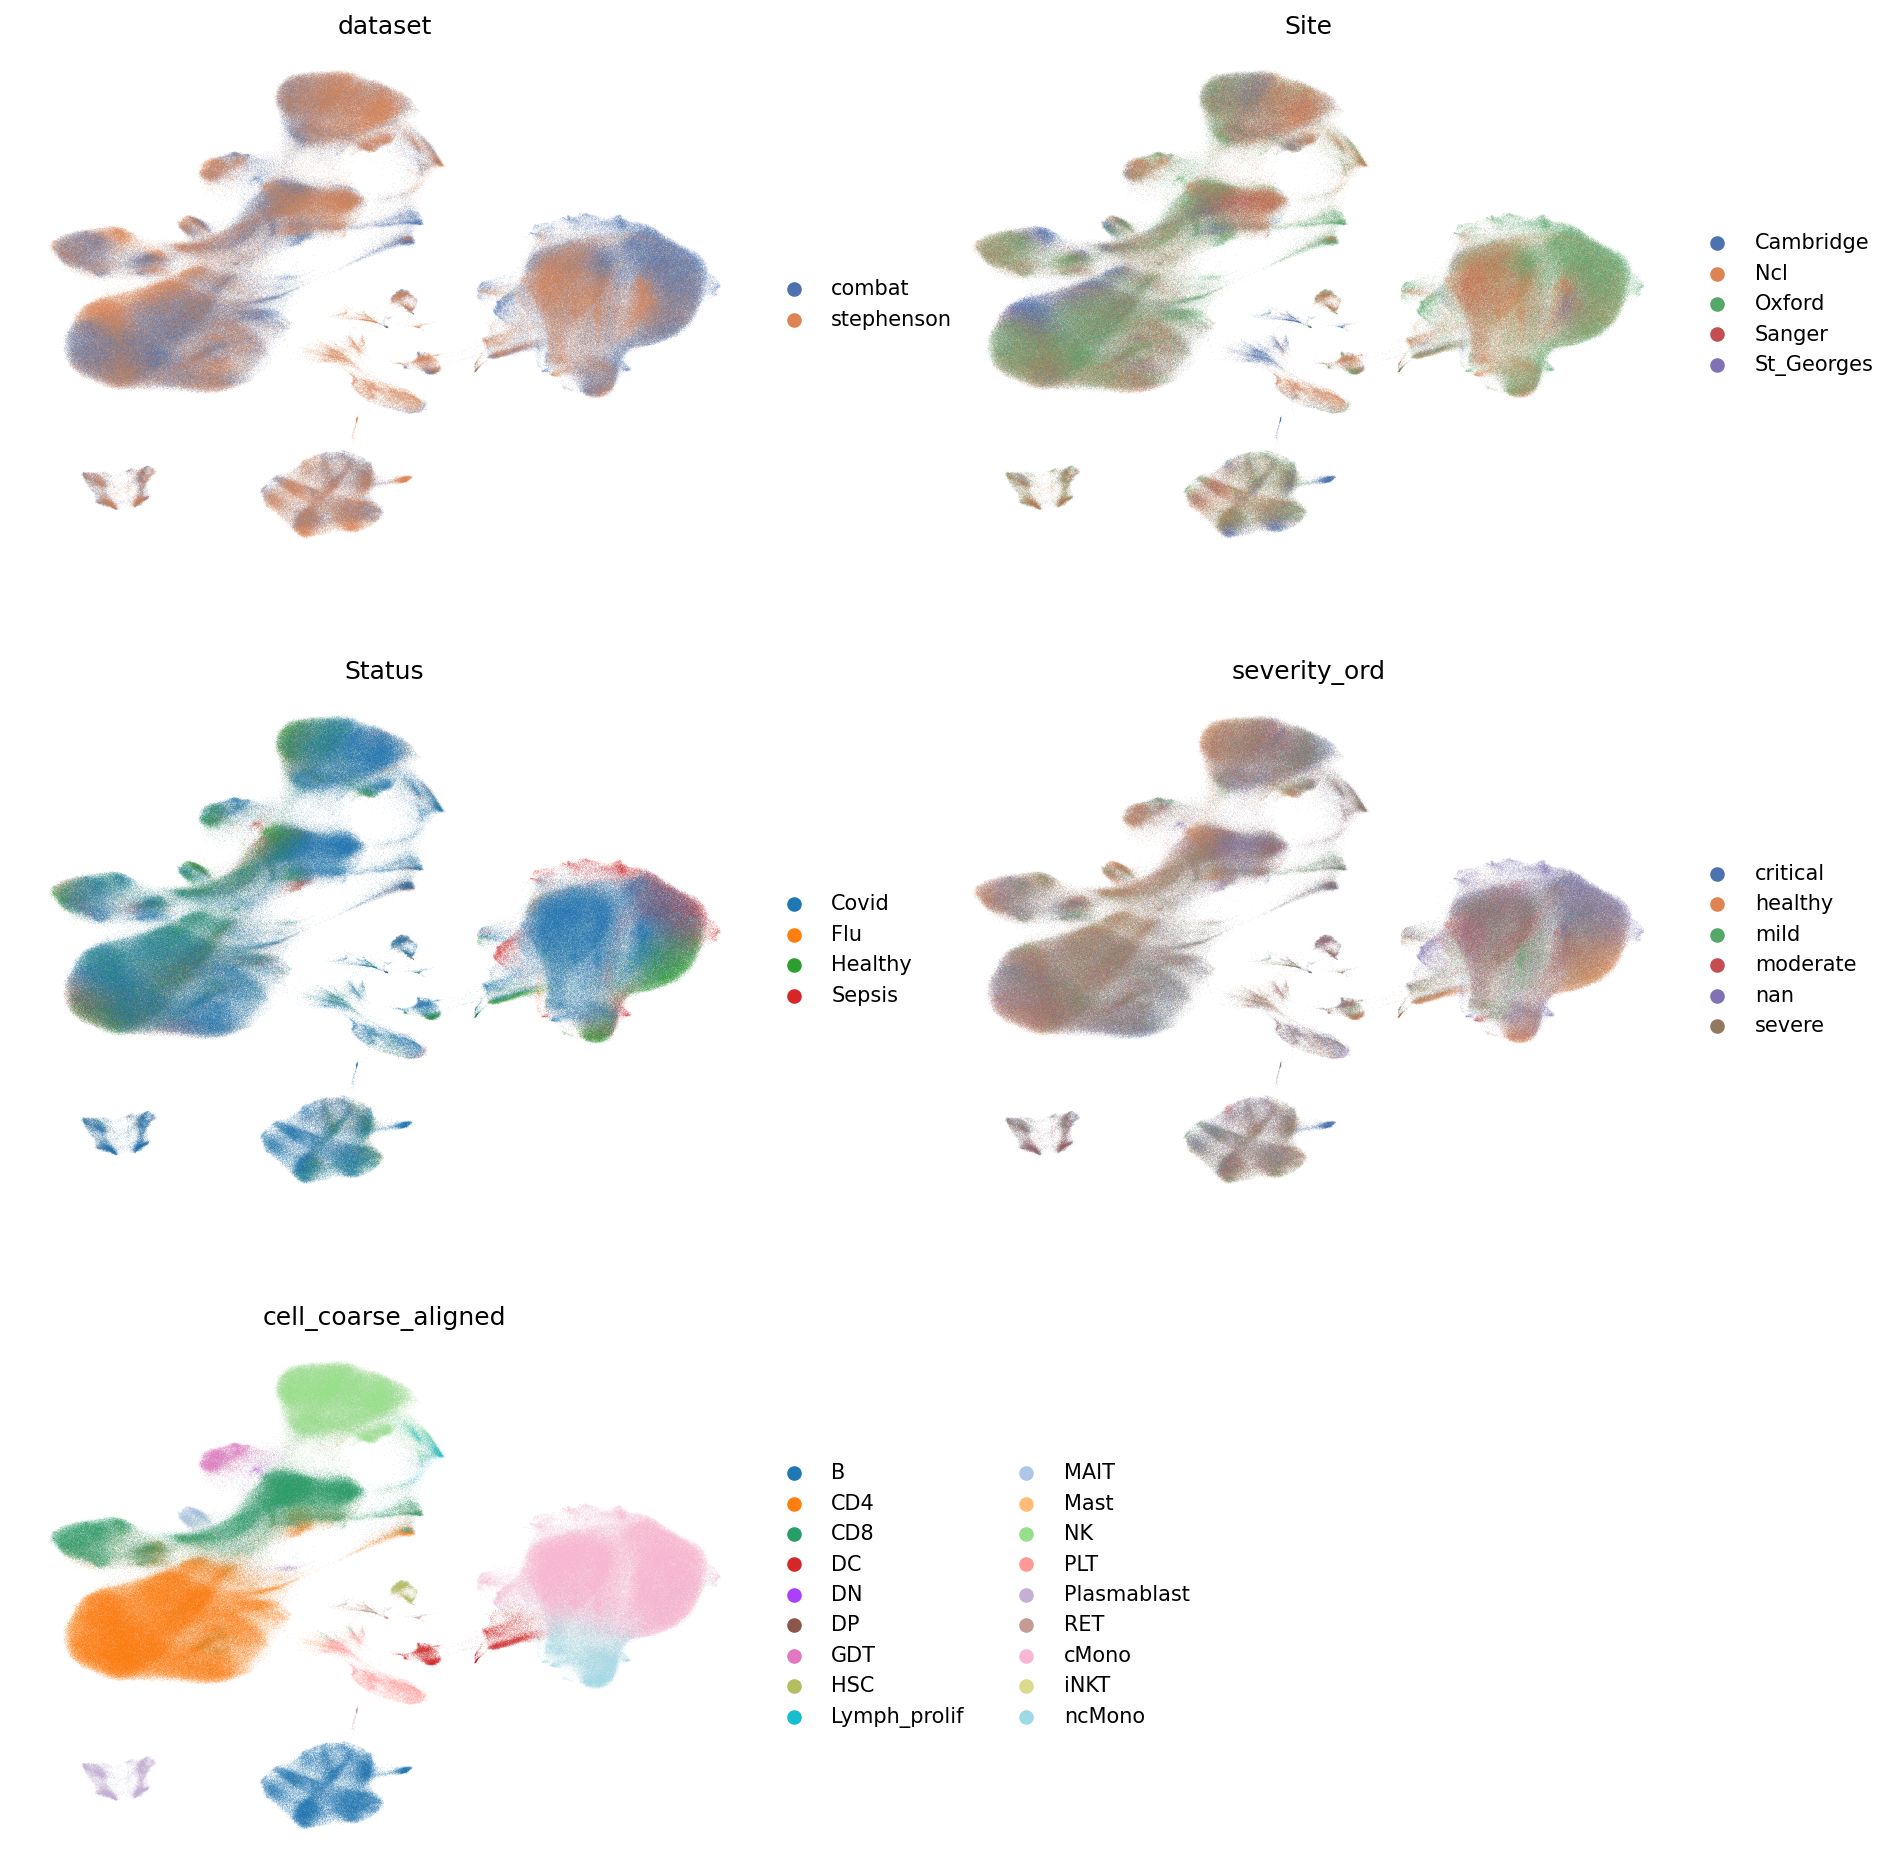

In [4]:
sc.pl.umap(
    adata,
    color=["dataset", "Site", "Status", "severity_ord", "cell_coarse_aligned"],
    frameon=False, ncols=2,
)


## 2. Preprocess raw counts

Normalise to 10 k UMIs and `log1p`. The log-normalised matrix becomes `adata.X`; raw counts move to `adata.layers["counts"]` so any count-based method can still pick them up.


In [5]:
RAW_LAYER     = "X_raw_counts"
LOGNORM_LAYER = "X_log1p"
SCANVI_OBSM   = "X_scANVI_dataset"

adata.layers["counts"] = adata.layers[RAW_LAYER]
adata.X = adata.layers[RAW_LAYER].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers[LOGNORM_LAYER] = adata.X
print("X is log-normalised: max =", float(adata.X.max()), " min =", float(adata.X.min()))


X is log-normalised: max = 9.158217430114746  min = 0.0


## 2b. Resolve Ensembl IDs to HGNC symbols + score the IFN-I signature

`combat_stephenson` ships `adata.var_names` as Ensembl gene IDs. We resolve them to HGNC symbols via [`mygene.info`](https://mygene.info) once, attach both columns to `adata.var`, and reuse them everywhere downstream (gene-pseudotime correlation, marker tables, signature scoring).

Then score the well-known type-I interferon (ISG) response signature that's strongly upregulated in COVID-19. We pass `sc.tl.score_genes` Ensembl IDs (mapped from symbols) and aggregate per donor to a single `ifn_score` column.

In [6]:
import mygene

mg = mygene.MyGeneInfo()
hits = mg.querymany(
    list(adata.var_names),
    scopes="ensembl.gene",
    fields="symbol",
    species="human",
    returnall=True,
)["out"]
sym_map = {}
for h in hits:
    if "symbol" in h and h["query"] not in sym_map:
        sym_map[h["query"]] = h["symbol"]
adata.var["ensembl_id"] = adata.var_names
adata.var["gene_name"] = [sym_map.get(g, g) for g in adata.var_names]
symbol_to_ensembl = (
    adata.var.reset_index()
    .drop_duplicates(subset="gene_name", keep="first")
    .set_index("gene_name")["ensembl_id"]
    .to_dict()
)
print(f"resolved {sum(adata.var['gene_name'] != adata.var['ensembl_id'])}/{adata.n_vars} Ensembl IDs to gene symbols")


resolved 1853/1856 Ensembl IDs to gene symbols


In [7]:
IFN_SIGNATURE = [
    "BST2", "CMPK2", "EIF2AK2", "EPSTI1", "HERC5", "IFI35", "IFI44L", "IFI6",
    "IFIT3", "ISG15", "LY6E", "MX1", "MX2", "OAS1", "OAS2", "PARP9", "PLSCR1",
    "SAMD9", "SAMD9L", "SP110", "STAT1", "TRIM22", "UBE2L6", "XAF1", "IRF7",
]
ifn_ensembl = [symbol_to_ensembl[g] for g in IFN_SIGNATURE if g in symbol_to_ensembl]
missing = sorted(set(IFN_SIGNATURE) - set(symbol_to_ensembl))
print(f"IFN-I signature: {len(ifn_ensembl)}/{len(IFN_SIGNATURE)} genes mapped"
      + (f"  missing: {missing}" if missing else ""))

sc.tl.score_genes(adata, gene_list=ifn_ensembl, score_name="ifn_score",
                  use_raw=False, random_state=SEED)
print("cell-level ifn_score:", adata.obs["ifn_score"].describe().round(3).to_dict())


IFN-I signature: 10/25 genes mapped  missing: ['BST2', 'EIF2AK2', 'HERC5', 'IFI35', 'LY6E', 'MX2', 'OAS2', 'PARP9', 'SAMD9', 'SAMD9L', 'SP110', 'STAT1', 'TRIM22', 'UBE2L6', 'XAF1']


cell-level ifn_score: {'count': 1399435.0, 'mean': -0.05, 'std': 0.762, 'min': -1.502, '25%': -0.598, '50%': -0.269, '75%': 0.298, 'max': 4.636}


## 3. Sample-level metadata + train / val / test split


In [8]:
metadata = patpy.pp.extract_metadata(
    adata, sample_key=info.sample_key, columns=info.sample_metadata_columns,
)
rng = np.random.default_rng(SEED)
metadata["split"] = rng.choice(["train", "val", "test"], size=len(metadata), p=[0.5, 0.25, 0.25])
print(metadata["split"].value_counts())
metadata.head()


split
train    127
test      62
val       62
Name: count, dtype: int64


,dataset,Site,SARSCoV2PCR,Outcome,TimeSinceOnset,split,Status,severity_ord,severity_idx,outcome_bin,Status_encoded
sample_id,,,,,,,,,,,
S00109-Ja001E-PBCa,combat,Oxford,1,2.0,12.0,test,Covid,severe,3,0.0,0.0
S00112-Ja003E-PBCa,combat,Oxford,1,5.0,12.0,train,Covid,mild,1,0.0,0.0
S00005-Ja005E-PBCa,combat,Oxford,1,2.0,14.0,test,Covid,critical,4,0.0,0.0
S00061-Ja003E-PBCa,combat,Oxford,1,4.0,6.0,val,Covid,severe,3,0.0,0.0
S00056-Ja003E-PBCa,combat,Oxford,1,3.0,23.0,train,Covid,severe,3,0.0,0.0


## 4. Two pseudobulk baselines + CLR composition


In [9]:
def mean_pseudobulk(adata, info, *, layer):
    pb = patpy.tl.Pseudobulk(
        sample_key=info.sample_key,
        cell_group_key=info.cell_type_key,
        layer=layer, seed=SEED,
    )
    pb.prepare_anndata(adata)
    pb.calculate_distance_matrix(force=True)
    return pd.DataFrame(np.asarray(pb.sample_representation), index=list(pb.samples))

pb_lognorm = mean_pseudobulk(adata, info, layer=LOGNORM_LAYER)
pb_scanvi  = mean_pseudobulk(adata, info, layer=SCANVI_OBSM)
print("pseudobulk_lognorm:", pb_lognorm.shape, " pseudobulk_scanvi:", pb_scanvi.shape)


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-stcb-code/src/patpy/tl/sample_representation.py:1316: UserWarning: Using data from adata.layers['X_log1p']
  data = self._get_data()


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-stcb-code/src/patpy/tl/sample_representation.py:1316: UserWarning: Using data from adata.obsm['X_scANVI_dataset']
  data = self._get_data()


pseudobulk_lognorm: (251, 1856)  pseudobulk_scanvi: (251, 30)


In [10]:
cmp = patpy.tl.CellGroupComposition(
    sample_key=info.sample_key,
    cell_group_key=info.cell_type_key,
    apply_clr=True, seed=SEED,
)
cmp.prepare_anndata(adata)
cmp.calculate_distance_matrix(force=True)
comp_clr = pd.DataFrame(np.asarray(cmp.sample_representation), index=list(cmp.sample_representation.index))
print("composition_clr:", comp_clr.shape)


composition_clr: (251, 18)


In [11]:
# meta_adata.X = mean pseudobulk on log-norm counts (the baseline)
sample_order = list(metadata.index)
pb_lognorm = pb_lognorm.reindex(sample_order)

meta_adata = ad.AnnData(
    X=pb_lognorm.values.astype(np.float32),
    obs=metadata,
    var=pd.DataFrame(index=adata.var_names),
)
meta_adata.layers["pseudobulk_lognorm"] = meta_adata.X
meta_adata.uns["sample_key"] = info.sample_key
meta_adata.uns["cell_type_key"] = info.cell_type_key

def attach(meta_adata, key, df):
    aligned = df.reindex(list(meta_adata.obs_names))
    if aligned.isna().any().any():
        raise ValueError(f"{key}: missing samples")
    meta_adata.obsm[key] = aligned.values.astype(np.float32)

attach(meta_adata, "X_pseudobulk_lognorm", pb_lognorm)
attach(meta_adata, "X_pseudobulk_scanvi",  pb_scanvi)
attach(meta_adata, "X_composition_clr",    comp_clr)
meta_adata


AnnData object with n_obs × n_vars = 251 × 1856
    obs: 'dataset', 'Site', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', 'split', 'Status', 'severity_ord', 'severity_idx', 'outcome_bin', 'Status_encoded'
    uns: 'sample_key', 'cell_type_key'
    obsm: 'X_pseudobulk_lognorm', 'X_pseudobulk_scanvi', 'X_composition_clr'
    layers: 'pseudobulk_lognorm'

In [12]:
# Donor-level IFN-I score = mean across the donor's cells.
ifn_per_donor = adata.obs.groupby(info.sample_key, observed=True)["ifn_score"].mean()
meta_adata.obs["ifn_score"] = ifn_per_donor.reindex(meta_adata.obs_names).astype(np.float64)
print(meta_adata.obs["ifn_score"].describe().round(3))


count    251.000
mean      -0.047
std        0.610
min       -0.717
25%       -0.448
50%       -0.329
75%        0.158
max        1.959
Name: ifn_score, dtype: float64


## 5. SampleCLR — self-supervised pretrain + supervised fine-tune

`patpy.tl.SampleCLR` (a thin wrapper around `sampleclr.ContrastiveModel`) is trained on the scANVI embedding with a `Site`-aware sampler. Snapshot the projector after pretrain (SSL embedding), then fine-tune with a `severity_idx` classification head and snapshot again. Best states are persisted to disk.


In [13]:
SAMPLECLR_LAYER = SCANVI_OBSM
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

sclr = patpy.tl.SampleCLR(
    sample_key=info.sample_key,
    label_keys=["severity_idx"],
    tasks=["classification"],
    layer=SAMPLECLR_LAYER,
    batch_key="Site",
    n_cells_per_sample=[500, 750],
    batch_size=16,
    device=device,
    seed=SEED,
    # forwarded to ContrastiveModel via **model_kwargs
    train_ids=list(metadata[metadata["split"] == "train"].index),
    val_ids=list(metadata[metadata["split"] == "val"].index),
    early_stopping_patience=50,
    contrastive_loss_temperature=0.3,
    attention_sparsity_lambda=0,
)

# Stage 1 only — SSL pretrain. The wrapper builds the underlying ContrastiveModel,
# runs pretrain, and leaves the model at the best-val checkpoint.
sclr.prepare_anndata(adata, pretrain=True, fine_tune=False, pretrain_val_metric="loss")
torch.save(
    {
        "projector": sclr._sclr_model.projector.state_dict(),
        "aggregator": sclr._sclr_model.aggregator.state_dict(),
    },
    MODELS_DIR / "sampleclr_ssl_state.pt",
)
print("saved sampleclr_ssl_state.pt")

device: cuda


Stage 1: Contrastive-only training (pretrain)


Epoch 1/100 - Loss: 1.5888, Contr: 1.5888, Top1: 1.000, Top5: 1.000 | Time: 18.84s (16 batches, 1088.1ms/batch)


Full Loss Report:
contrastive – train: 1.5888 – val: 3.2621
classification (severity_idx) – train: 0.0000 – val: 3.5910
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000


Epoch 2/100 - Loss: 1.4921, Contr: 1.4921, Top1: 1.000, Top5: 1.000 | Time: 0.21s (16 batches, 5.9ms/batch)
Full Loss Report:
contrastive – train: 1.4921 – val: 2.1268
classification (severity_idx) – train: 0.0000 – val: 3.6147
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000


...

Epoch 62/100 - Loss: 0.6661, Contr: 0.6661, Top1: 1.000, Top5: 1.000 | Time: 0.21s (16 batches, 5.8ms/batch)
Full Loss Report:
contrastive – train: 0.6661 – val: 1.1820
classification (severity_idx) – train: 0.0000 – val: 3.6168
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000


Epoch 63/100 - Loss: 0.6650, Contr: 0.6650, Top1: 1.000, Top5: 1.000 | Time: 0.21s (16 batches, 5.8ms/batch)
Full Loss Report:
contrastive – train: 0.6650 – val: 1.1511
classification (severity_idx) – train: 0.0000 – val: 3.6187
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000


Epoch 64/100 - Loss: 0.6667, Contr: 0.6667, Top1: 1.000, Top5: 1.000 | Time: 0.21s (16 batches, 5.8ms/batch)
Full Loss Report:
contrastive – train: 0.6667 – val: 1.2117
classification (severity_idx) – train: 0.0000 – val: 3.6217
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000


Epoch 65/100 - Loss: 0.6693, Contr: 0.6693, Top1: 1.000, Top5: 1.000 | Time: 0.21s (16 batches, 5.8ms/batch)
Early stopping triggered in pretrain.


saved sampleclr_ssl_state.pt


In [14]:
# Inference must cover ALL donors (train + val + test). patpy.tl.SampleCLR's
# get_sample_representations() restricts to training donors, so we call the
# underlying utility directly with meta_obs_names=metadata.index.
sclr_ssl_raw = get_sample_representations_from_adata(
    projector=sclr._sclr_model.projector,
    aggregator=sclr._sclr_model.aggregator,
    adata=adata,
    sample_key=info.sample_key,
    layer=SAMPLECLR_LAYER,
    subset_size=750,
    meta_obs_names=metadata.index,
    device=device,
)
sclr_ssl = pd.DataFrame(np.asarray(sclr_ssl_raw), index=list(metadata.index))
attach(meta_adata, "X_sampleclr_ssl", sclr_ssl)
print("sampleclr_ssl:", sclr_ssl.shape)
gc.collect()

sampleclr_ssl: (251, 128)


7722

In [15]:
# Stage 2 — supervised fine-tune on the head that was configured at __init__.
sclr.fine_tune("severity_idx", "classification", val_metric="loss")
torch.save(
    {
        "projector": sclr._sclr_model.projector.state_dict(),
        "aggregator": sclr._sclr_model.aggregator.state_dict(),
    },
    MODELS_DIR / "sampleclr_ft_state.pt",
)
print("saved sampleclr_ft_state.pt")

(MODELS_DIR / "sampleclr_config.json").write_text(json.dumps({
    "sample_key": info.sample_key, "layer": SAMPLECLR_LAYER,
    "label": "severity_idx", "site_col": "Site",
    "n_cells_per_sample": [500, 750], "batch_size": 16,
    "early_stopping_patience": 50, "contrastive_loss_temperature": 0.3,
}, indent=2))

Stage joint: training (fine_tune)
Freezing the backbone for 10 epochs



Epoch 1/100 | Time: 0.32s (16 batches, 12.7ms/batch)
contrastive – train: 0.6672 – val: 1.1605
classification (severity_idx) – train: 3.6081 – val: 3.6173
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------



Epoch 2/100 | Time: 0.21s (16 batches, 6.2ms/batch)
contrastive – train: 0.6614 – val: 1.1568
classification (severity_idx) – train: 3.6278 – val: 3.6092
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------



Epoch 3/100 | Time: 0.17s (16 batches, 3.2ms/batch)
contrastive – train: 0.6670 – val: 1.2237
classification (severity_idx) – train: 3.5759 – val: 3.6100
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------



Epoch 4/100 | Time: 0.17s (16 batches, 3.2ms/batch)
contrastive – train: 0.6660 – val: 1.1944
classification (severity_idx) – train: 3.5921 – val: 3.6099
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------


...


Epoch 83/100 | Time: 0.23s (16 batches, 6.8ms/batch)
contrastive – train: 0.6579 – val: 1.1885
classification (severity_idx) – train: 0.3610 – val: 2.6422
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------



Epoch 84/100 | Time: 0.22s (16 batches, 6.8ms/batch)
contrastive – train: 0.6559 – val: 1.1853
classification (severity_idx) – train: 0.3237 – val: 2.6448
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------



Epoch 85/100 | Time: 0.23s (16 batches, 6.9ms/batch)
contrastive – train: 0.6570 – val: 1.1675
classification (severity_idx) – train: 0.3954 – val: 2.7110
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------
Early stopping triggered in fine_tune.


saved sampleclr_ft_state.pt


251

In [16]:
sclr_ft_raw = get_sample_representations_from_adata(
    projector=sclr._sclr_model.projector,
    aggregator=sclr._sclr_model.aggregator,
    adata=adata,
    sample_key=info.sample_key,
    layer=SAMPLECLR_LAYER,
    subset_size=750,
    meta_obs_names=metadata.index,
    device=device,
)
sclr_ft = pd.DataFrame(np.asarray(sclr_ft_raw), index=list(metadata.index))
attach(meta_adata, "X_sampleclr_ft", sclr_ft)
print("sampleclr_ft:", sclr_ft.shape)
gc.collect()

sampleclr_ft: (251, 128)


7020

## 5b. Interpreting SampleCLR head weights

`patpy.tl.SampleCLR`'s aggregator is a **multi-head attention pool**: each head
learns to up-weight a different subset of a donor's cells when building that
donor's representation. Reading those per-cell weights back out tells us *which
cells* drive the fine-tuned, severity-aware embedding.

We (1) extract every head's per-cell weight into `adata.obsm["X_cell_weights"]`,
(2) summarise them per cell type with a dot plot, and (3) ask which head's
weights track COVID-19 severity, and in which cell types.

In [17]:
# Per-cell head weights from the fine-tuned aggregator. Every donor's cells
# (train + val + test) are pushed through the aggregator with
# return_weights=True; the (n_cells_i, n_heads) weights are scattered back into
# a full (n_obs, n_heads) matrix on adata.
model = sclr._sclr_model
model.aggregator.eval()
model.aggregator.return_weights = True

weight_list, index_list = [], []
with torch.no_grad():
    for sid in adata.obs[info.sample_key].unique():
        mask = adata.obs[info.sample_key] == sid
        cells = adata[mask].obsm[SAMPLECLR_LAYER]
        if hasattr(cells, "toarray"):
            cells = cells.toarray()
        cells = torch.as_tensor(
            np.asarray(cells, dtype=np.float32), device=model.device
        ).unsqueeze(0)
        _, w = model.aggregator(cells)
        weight_list.append(w.squeeze(0).detach().cpu().numpy())
        index_list.append(np.where(mask.values)[0])

model.aggregator.return_weights = False

n_heads = weight_list[0].shape[1]
cell_weights = np.zeros((adata.n_obs, n_heads), dtype=np.float32)
for idx, w in zip(index_list, weight_list):
    cell_weights[idx] = w
adata.obsm["X_cell_weights"] = cell_weights

HEAD_NAMES = [f"H{i}" for i in range(n_heads)]
for i, name in enumerate(HEAD_NAMES):
    adata.obs[name] = cell_weights[:, i]
print("X_cell_weights:", cell_weights.shape, " heads:", HEAD_NAMES)

X_cell_weights: (1399435, 8)  heads: ['H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7']


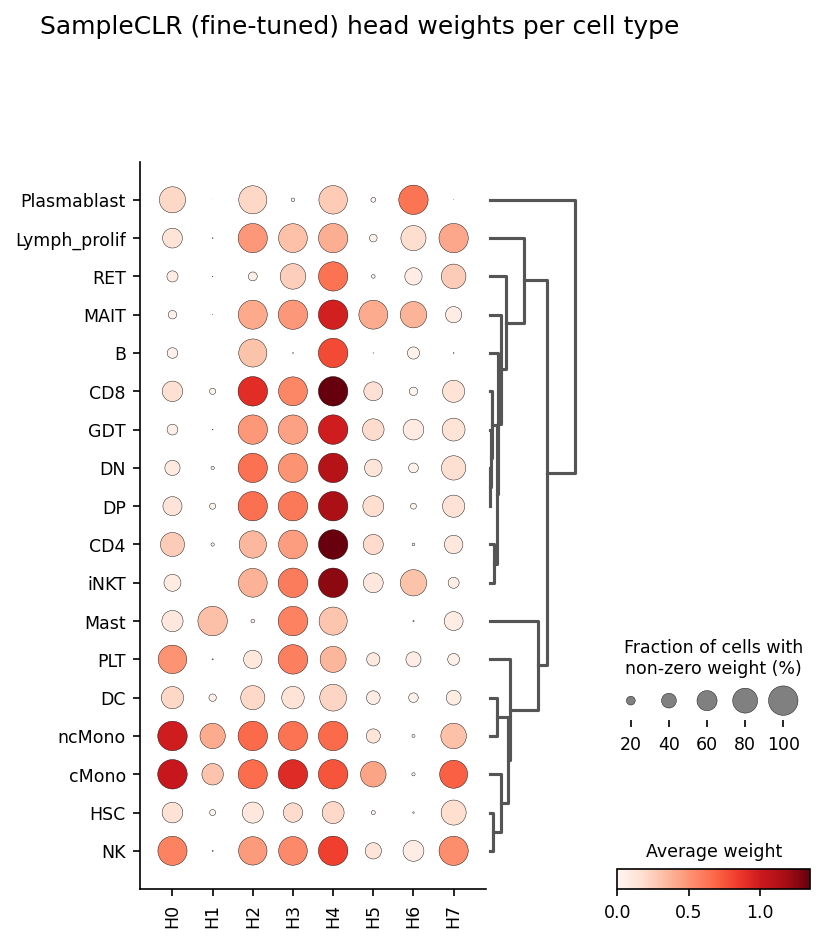

In [18]:
# Dot plot per cell type: dot colour = average head weight, dot size = fraction
# of cells with non-zero weight. The dendrogram clusters cell types by their
# weight profile across heads.
annotation = info.cell_type_key
sc.tl.dendrogram(adata, groupby=annotation, use_rep="X_cell_weights")
with plt.rc_context({"figure.dpi": 150}):
    sc.pl.dotplot(
        adata,
        HEAD_NAMES,
        groupby=annotation,
        dendrogram=True,
        size_title="Fraction of cells with\nnon-zero weight (%)",
        colorbar_title="Average weight",
        title="SampleCLR (fine-tuned) head weights per cell type",
    )

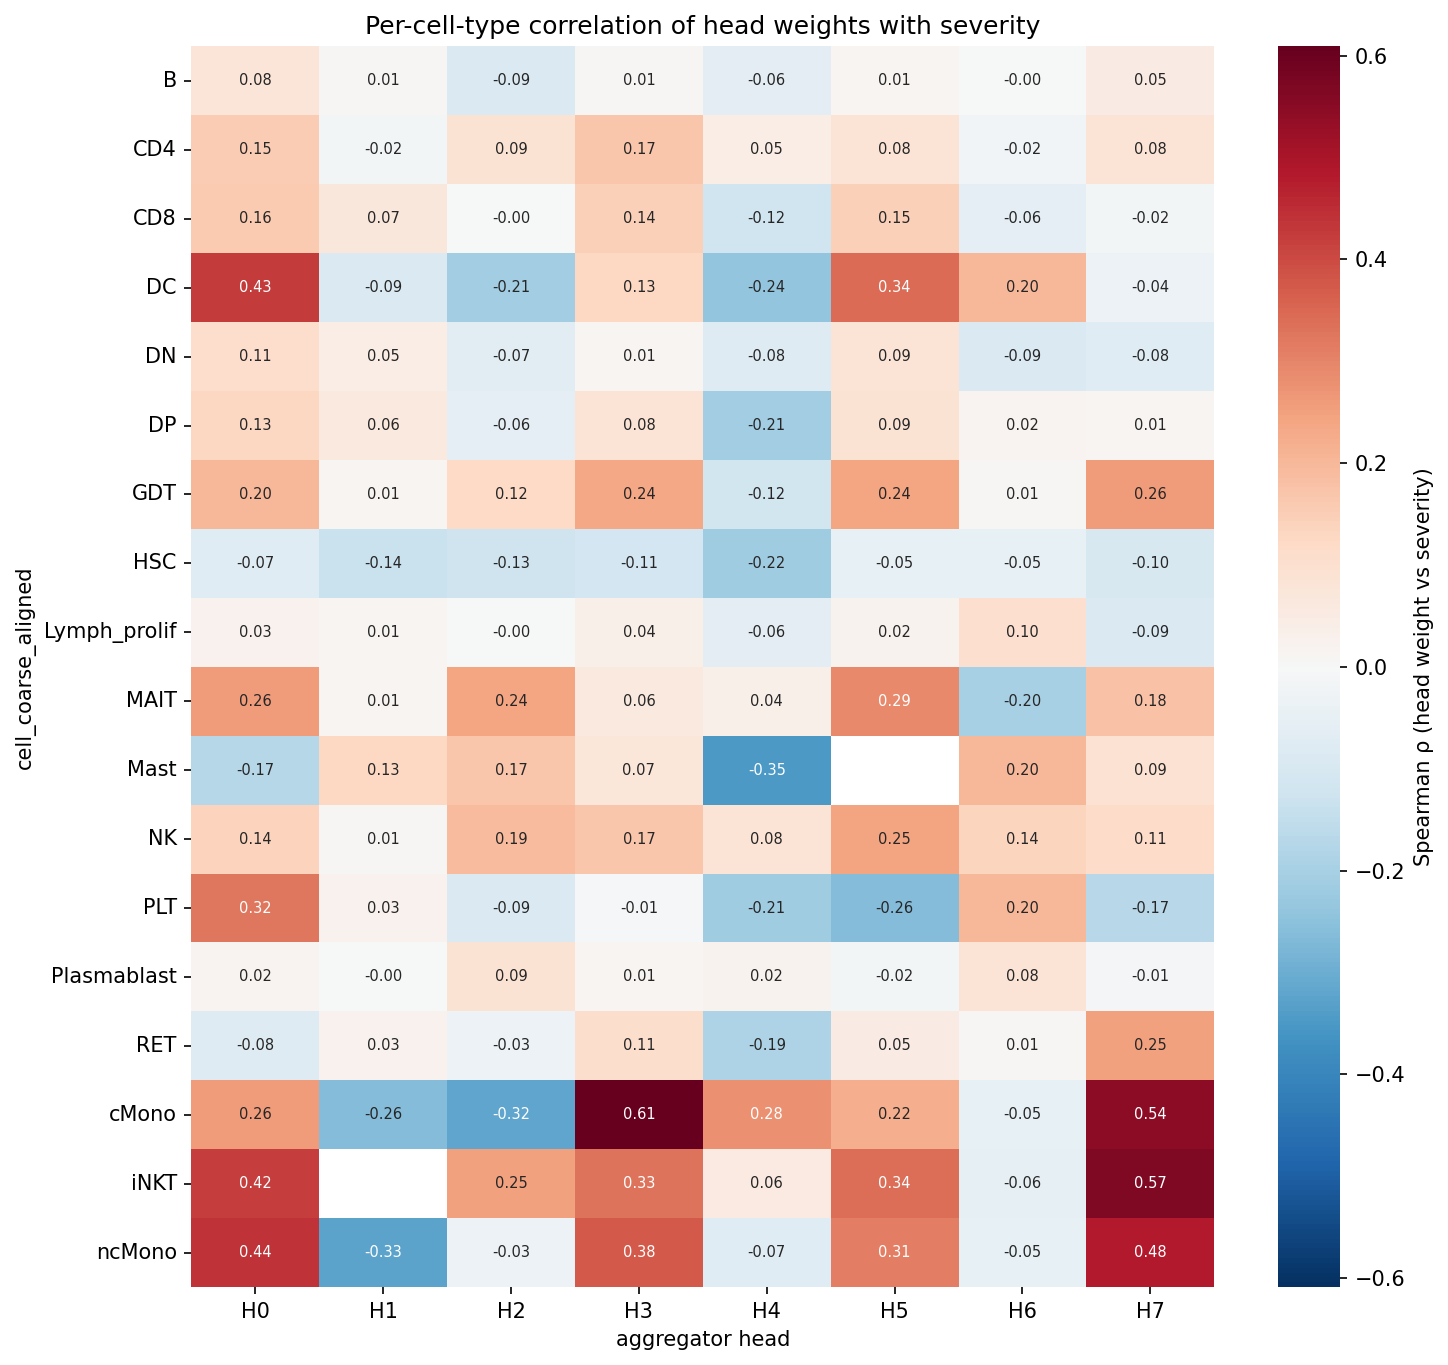

most severity-associated head: H3 (peak |rho|=0.61 in 'cMono')


cMono           0.608904
ncMono          0.375086
iNKT            0.331816
GDT             0.235722
NK              0.170972
CD4             0.169559
CD8             0.143795
DC              0.126172
RET             0.108899
DP              0.083439
Mast            0.071688
MAIT            0.061244
Lymph_prolif    0.037237
Plasmablast     0.013878
DN              0.011074
B               0.009206
PLT            -0.007129
HSC            -0.112445
Name: H3, dtype: float64

In [19]:
# Correlate each head's per-cell weight with donor severity, within each cell
# type. severity_idx is the ordinal severity (0=healthy ... 4=critical); -1
# marks unknown severity and is dropped before correlating.
from scipy.stats import spearmanr

severity_num = pd.to_numeric(adata.obs["severity_idx"].astype(str), errors="coerce")
severity_num = severity_num.where(severity_num >= 0)   # -1 -> NaN
cell_types = adata.obs[annotation].astype(str)

corr = pd.DataFrame(index=sorted(cell_types.unique()), columns=HEAD_NAMES, dtype=float)
for ct in corr.index:
    m = (cell_types == ct).values & severity_num.notna().values
    sv = severity_num.values[m]
    if m.sum() < 10 or np.unique(sv).size < 2:
        continue
    for h, name in enumerate(HEAD_NAMES):
        wv = cell_weights[m, h]
        if np.std(wv) == 0:
            continue
        corr.loc[ct, name] = spearmanr(wv, sv).correlation

vmax = float(np.nanmax(np.abs(corr.values)))
fig, ax = plt.subplots(figsize=(1.0 * n_heads + 2, 0.4 * len(corr) + 2))
sns.heatmap(
    corr.astype(float), cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
    annot=True, fmt=".2f", annot_kws={"fontsize": 7},
    cbar_kws={"label": "Spearman \u03c1 (head weight vs severity)"}, ax=ax,
)
ax.set_xlabel("aggregator head"); ax.set_ylabel(annotation)
ax.set_title("Per-cell-type correlation of head weights with severity")
plt.tight_layout(); plt.show()

# Head whose weights track severity most strongly (largest |rho| over cell types).
best_head = corr.abs().max(axis=0).idxmax()
best_ct = corr[best_head].abs().idxmax()
print(f"most severity-associated head: {best_head} "
      f"(peak |rho|={corr[best_head].abs().max():.2f} in '{best_ct}')")
corr[best_head].dropna().sort_values(ascending=False)

/localscratch/vladimir.shitov/ipykernel_1036264/446183589.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="severity", y="weight", order=SEVERITY_ORDER,


/localscratch/vladimir.shitov/ipykernel_1036264/446183589.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="severity", y="weight", order=SEVERITY_ORDER,
/localscratch/vladimir.shitov/ipykernel_1036264/446183589.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="severity", y="weight", order=SEVERITY_ORDER,


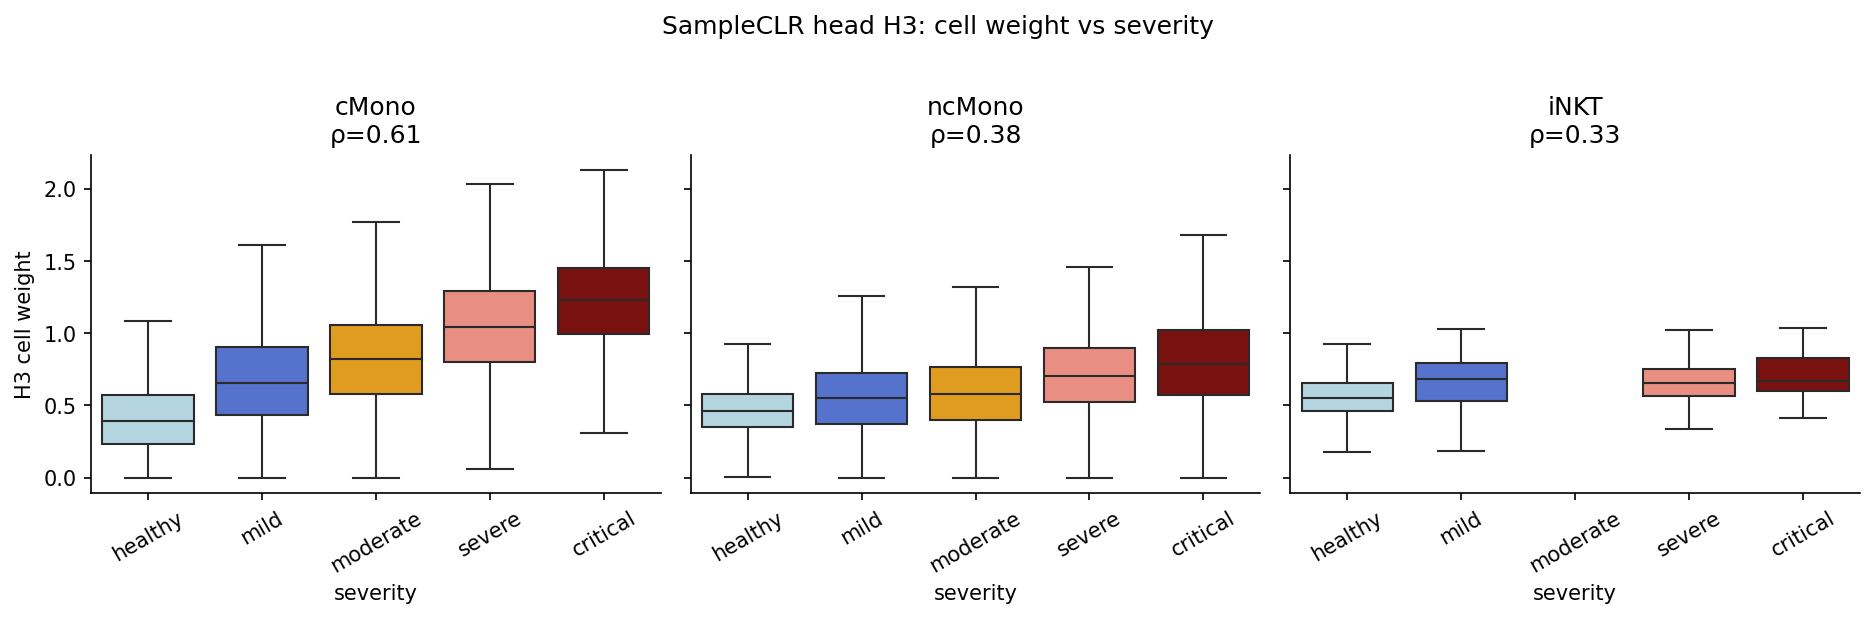

In [20]:
# For the most severity-associated head, show its per-cell weight against
# severity in the cell types where that association is strongest.
top_cts = corr[best_head].abs().sort_values(ascending=False).head(3).index.tolist()
sev_ord = adata.obs["severity_ord"].astype(str)
hi = HEAD_NAMES.index(best_head)

fig, axes = plt.subplots(1, len(top_cts), figsize=(4.2 * len(top_cts), 4),
                         sharey=True, squeeze=False)
for ax, ct in zip(axes[0], top_cts):
    m = (cell_types == ct).values & sev_ord.isin(SEVERITY_ORDER).values
    df = pd.DataFrame({
        "severity": pd.Categorical(sev_ord[m], categories=SEVERITY_ORDER, ordered=True),
        "weight": cell_weights[m, hi],
    })
    sns.boxplot(data=df, x="severity", y="weight", order=SEVERITY_ORDER,
                palette=SEVERITY_PALETTE, showfliers=False, ax=ax)
    ax.set_title(f"{ct}\n\u03c1={corr.loc[ct, best_head]:.2f}")
    ax.set_xlabel("severity"); ax.set_ylabel(f"{best_head} cell weight")
    ax.tick_params(axis="x", rotation=30)
fig.suptitle(f"SampleCLR head {best_head}: cell weight vs severity", y=1.02)
plt.tight_layout(); plt.show()

## 6. GloScope_py — symmetric-KL on scANVI (GPU when available)

GPU path uses RAPIDS `cuml.NearestNeighbors`. CPU fallback uses `pynndescent`. We feed it the scANVI embedding so distances are comparable across cohorts, then take a 30-D MDS embedding.


In [21]:
def gloscope_check_gpu():
    try:
        import cuml, cupy  # noqa: F401
        return torch.cuda.is_available()
    except Exception as e:
        print(f"cuml/cupy unavailable ({type(e).__name__}); falling back to CPU")
        return False

use_gpu = gloscope_check_gpu()
print("use_gpu:", use_gpu)

gs = patpy.tl.GloScope_py(
    sample_key=info.sample_key, layer=SCANVI_OBSM,
    seed=SEED, k=25, use_gpu=use_gpu,
)
gs.prepare_anndata(adata)
distances_gloscope = gs.calculate_distance_matrix(force=True)
distances_gloscope = np.asarray(distances_gloscope, dtype=np.float64)
distances_gloscope = np.maximum(distances_gloscope, 0.0)
np.fill_diagonal(distances_gloscope, 0.0)
print("gloscope distances:", distances_gloscope.shape)


use_gpu: True


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-stcb-code/src/patpy/tl/sample_representation.py:2191: UserWarning: Using data from adata.obsm['X_scANVI_dataset']
  data = self._get_data()


gloscope distances: (251, 251)


In [22]:
from sklearn.manifold import MDS

mds = MDS(n_components=30, dissimilarity="precomputed", random_state=SEED, n_jobs=-1)
gloscope_emb = mds.fit_transform(distances_gloscope)
gloscope_df = pd.DataFrame(gloscope_emb, index=list(gs.samples))
attach(meta_adata, "X_gloscope_py", gloscope_df)
print("gloscope_py:", gloscope_df.shape)


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


gloscope_py: (251, 30)


## 7. PaSCient — supervised hierarchical patient encoder


In [23]:
pasc = patpy.tl.PaSCient(
    sample_key=info.sample_key,
    label_keys=["severity_idx"],
    tasks=["classification"],
    cell_group_key=info.cell_type_key,
    layer=None,
    n_cells=1500, batch_size=16, n_epochs=8,
    device=device, normalize=False, seed=SEED,
)
pasc.prepare_anndata(adata, train=True)
pascient_df = pasc.get_sample_representations()
pascient_df = pd.DataFrame(np.asarray(pascient_df), index=list(pascient_df.index))
attach(meta_adata, "X_pascient", pascient_df)
print("pascient:", pascient_df.shape)

if pasc._pascient_model is not None:
    torch.save(pasc._pascient_model.state_dict(), MODELS_DIR / "pascient_state.pt")
    print("saved pascient_state.pt")
    (MODELS_DIR / "pascient_config.json").write_text(json.dumps({
        "sample_key": info.sample_key, "cell_type_key": info.cell_type_key,
        "label": "severity_idx", "tasks": ["classification"],
        "n_cells": 1500, "batch_size": 16, "n_epochs": 8, "normalize": False,
    }, indent=2))


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-stcb-code/src/patpy/tl/supervised.py:1720: UserWarning: Using data from adata.X
  X = self._get_data()


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'gene2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['gene2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2patient_aggregation' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2patient_aggregatio

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 2. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

`Trainer.fit` stopped: `max_epochs=8` reached.


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy-stcb-code/src/patpy/tl/supervised.py:1720: UserWarning: Using data from adata.X
  X = self._get_data()


pascient: (251, 512)


saved pascient_state.pt


## 7b. Technical-only baseline

If we built donor embeddings purely from technical artefacts — `Site`, library-size summaries, average gene/QC stats — they should perfectly classify `Site` and `dataset` while carrying no clinical signal. This makes a useful floor on the KNN benchmark: any "real" representation should sit above it on `severity_idx` / `Status` and below it on `Site` / `dataset`.

In [24]:
# Per-donor technical features: one-hot Site + mean library / QC stats.
# combat_stephenson ships these QC columns as categories, so coerce first.
QC_COLS = [
    "log1p_total_counts",
    "log1p_n_genes_by_counts",
    "pct_counts_mt",
    "pct_counts_ribo",
    "pct_counts_in_top_50_genes",
]
qc_cell = adata.obs[QC_COLS].apply(lambda s: pd.to_numeric(s.astype(str), errors="coerce"))
qc_cell[info.sample_key] = adata.obs[info.sample_key].values
qc_per_donor = qc_cell.groupby(info.sample_key, observed=True)[QC_COLS].mean()
qc_per_donor["log_n_cells"] = np.log1p(
    adata.obs.groupby(info.sample_key, observed=True).size()
)

site_dummies = pd.get_dummies(
    adata.obs.drop_duplicates(info.sample_key)
    .set_index(info.sample_key)["Site"],
    prefix="Site",
).astype(float)

tech = qc_per_donor.join(site_dummies)
tech = tech.reindex(meta_adata.obs_names).fillna(tech.mean(numeric_only=True))
# z-score so distances aren't dominated by raw scale
tech = (tech - tech.mean()) / tech.std().replace(0, 1)
print("technical_baseline:", tech.shape, " columns:", list(tech.columns))

attach(meta_adata, "X_technical_baseline", tech)


technical_baseline: (251, 11)  columns: ['log1p_total_counts', 'log1p_n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_in_top_50_genes', 'log_n_cells', 'Site_Cambridge', 'Site_Ncl', 'Site_Oxford', 'Site_Sanger', 'Site_St_Georges']


## 8. Distances + neighbor graphs + per-rep UMAPs

`patpy.tl.evaluation` benchmarking helpers expect:

- `meta_adata.obsm["<rep>"]` — embedding (no `X_` prefix);
- `meta_adata.obsm["<rep>_distances"]` — pairwise distance matrix;
- `<rep>_neighbors` in `.uns` — scanpy neighbor graph.

For GloScope we re-use the symmetric-KL distance matrix; everything else uses Euclidean on the embedding.


In [25]:
# Categorical order + colour maps for plotting.
if hasattr(meta_adata.obs["Status"], "cat"):
    meta_adata.obs["Status"] = meta_adata.obs["Status"].cat.reorder_categories(
        ["Healthy", "Covid", "Flu", "Sepsis"], ordered=False,
    )
    meta_adata.uns["Status_colors"] = ["lightblue", "salmon", "orange", "darkred"]

if hasattr(meta_adata.obs["severity_ord"], "cat"):
    meta_adata.obs["severity_ord"] = meta_adata.obs["severity_ord"].cat.reorder_categories(
        ["nan", "healthy", "mild", "moderate", "severe", "critical"], ordered=True,
    )
    meta_adata.uns["severity_ord_colors"] = ["lightgray"] + [SEVERITY_PALETTE[s] for s in SEVERITY_ORDER]


In [26]:
from scipy.spatial.distance import pdist, squareform

REPS = [
    ("technical_baseline", "technical-only baseline"),
    ("pseudobulk_lognorm", "pseudobulk (log-norm)"),
    ("pseudobulk_scanvi",  "pseudobulk (scANVI)"),
    ("composition_clr",    "composition CLR"),
    ("gloscope_py",        "GloScope_py"),
    ("sampleclr_ssl",      "SampleCLR (SSL)"),
    ("sampleclr_ft",       "SampleCLR (fine-tuned)"),
    ("pascient",           "PaSCient"),
]

for rep, _ in REPS:
    obsm_key = f"X_{rep}"
    emb = np.asarray(meta_adata.obsm[obsm_key], dtype=np.float64)
    meta_adata.obsm[rep] = emb.astype(np.float32)

    if rep == "gloscope_py":
        dists = distances_gloscope.astype(np.float32)
    else:
        dists = squareform(pdist(emb, metric="euclidean")).astype(np.float32)
    meta_adata.obsm[f"{rep}_distances"] = dists

    nn_key = f"{rep}_neighbors"
    sc.pp.neighbors(meta_adata, use_rep=obsm_key, n_neighbors=15, key_added=nn_key)
    sc.tl.umap(meta_adata, neighbors_key=nn_key, random_state=SEED)
    meta_adata.obsm[f"X_umap_{rep}"] = meta_adata.obsm["X_umap"].copy()
    del meta_adata.obsm["X_umap"]
    print(f"  [ok] {rep}: distances {dists.shape}, neighbors+UMAP done")

meta_adata.uns["sample_representations"] = [r for r, _ in REPS]
meta_adata


  [ok] technical_baseline: distances (251, 251), neighbors+UMAP done


  [ok] pseudobulk_lognorm: distances (251, 251), neighbors+UMAP done


  [ok] pseudobulk_scanvi: distances (251, 251), neighbors+UMAP done


  [ok] composition_clr: distances (251, 251), neighbors+UMAP done


  [ok] gloscope_py: distances (251, 251), neighbors+UMAP done


  [ok] sampleclr_ssl: distances (251, 251), neighbors+UMAP done


  [ok] sampleclr_ft: distances (251, 251), neighbors+UMAP done


  [ok] pascient: distances (251, 251), neighbors+UMAP done


AnnData object with n_obs × n_vars = 251 × 1856
    obs: 'dataset', 'Site', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', 'split', 'Status', 'severity_ord', 'severity_idx', 'outcome_bin', 'Status_encoded', 'ifn_score'
    uns: 'sample_key', 'cell_type_key', 'Status_colors', 'severity_ord_colors', 'technical_baseline_neighbors', 'umap', 'pseudobulk_lognorm_neighbors', 'pseudobulk_scanvi_neighbors', 'composition_clr_neighbors', 'gloscope_py_neighbors', 'sampleclr_ssl_neighbors', 'sampleclr_ft_neighbors', 'pascient_neighbors', 'sample_representations'
    obsm: 'X_pseudobulk_lognorm', 'X_pseudobulk_scanvi', 'X_composition_clr', 'X_sampleclr_ssl', 'X_sampleclr_ft', 'X_gloscope_py', 'X_pascient', 'X_technical_baseline', 'technical_baseline', 'technical_baseline_distances', 'X_umap_technical_baseline', 'pseudobulk_lognorm', 'pseudobulk_lognorm_distances', 'X_umap_pseudobulk_lognorm', 'pseudobulk_scanvi', 'pseudobulk_scanvi_distances', 'X_umap_pseudobulk_scanvi', 'composition_clr', 'composition

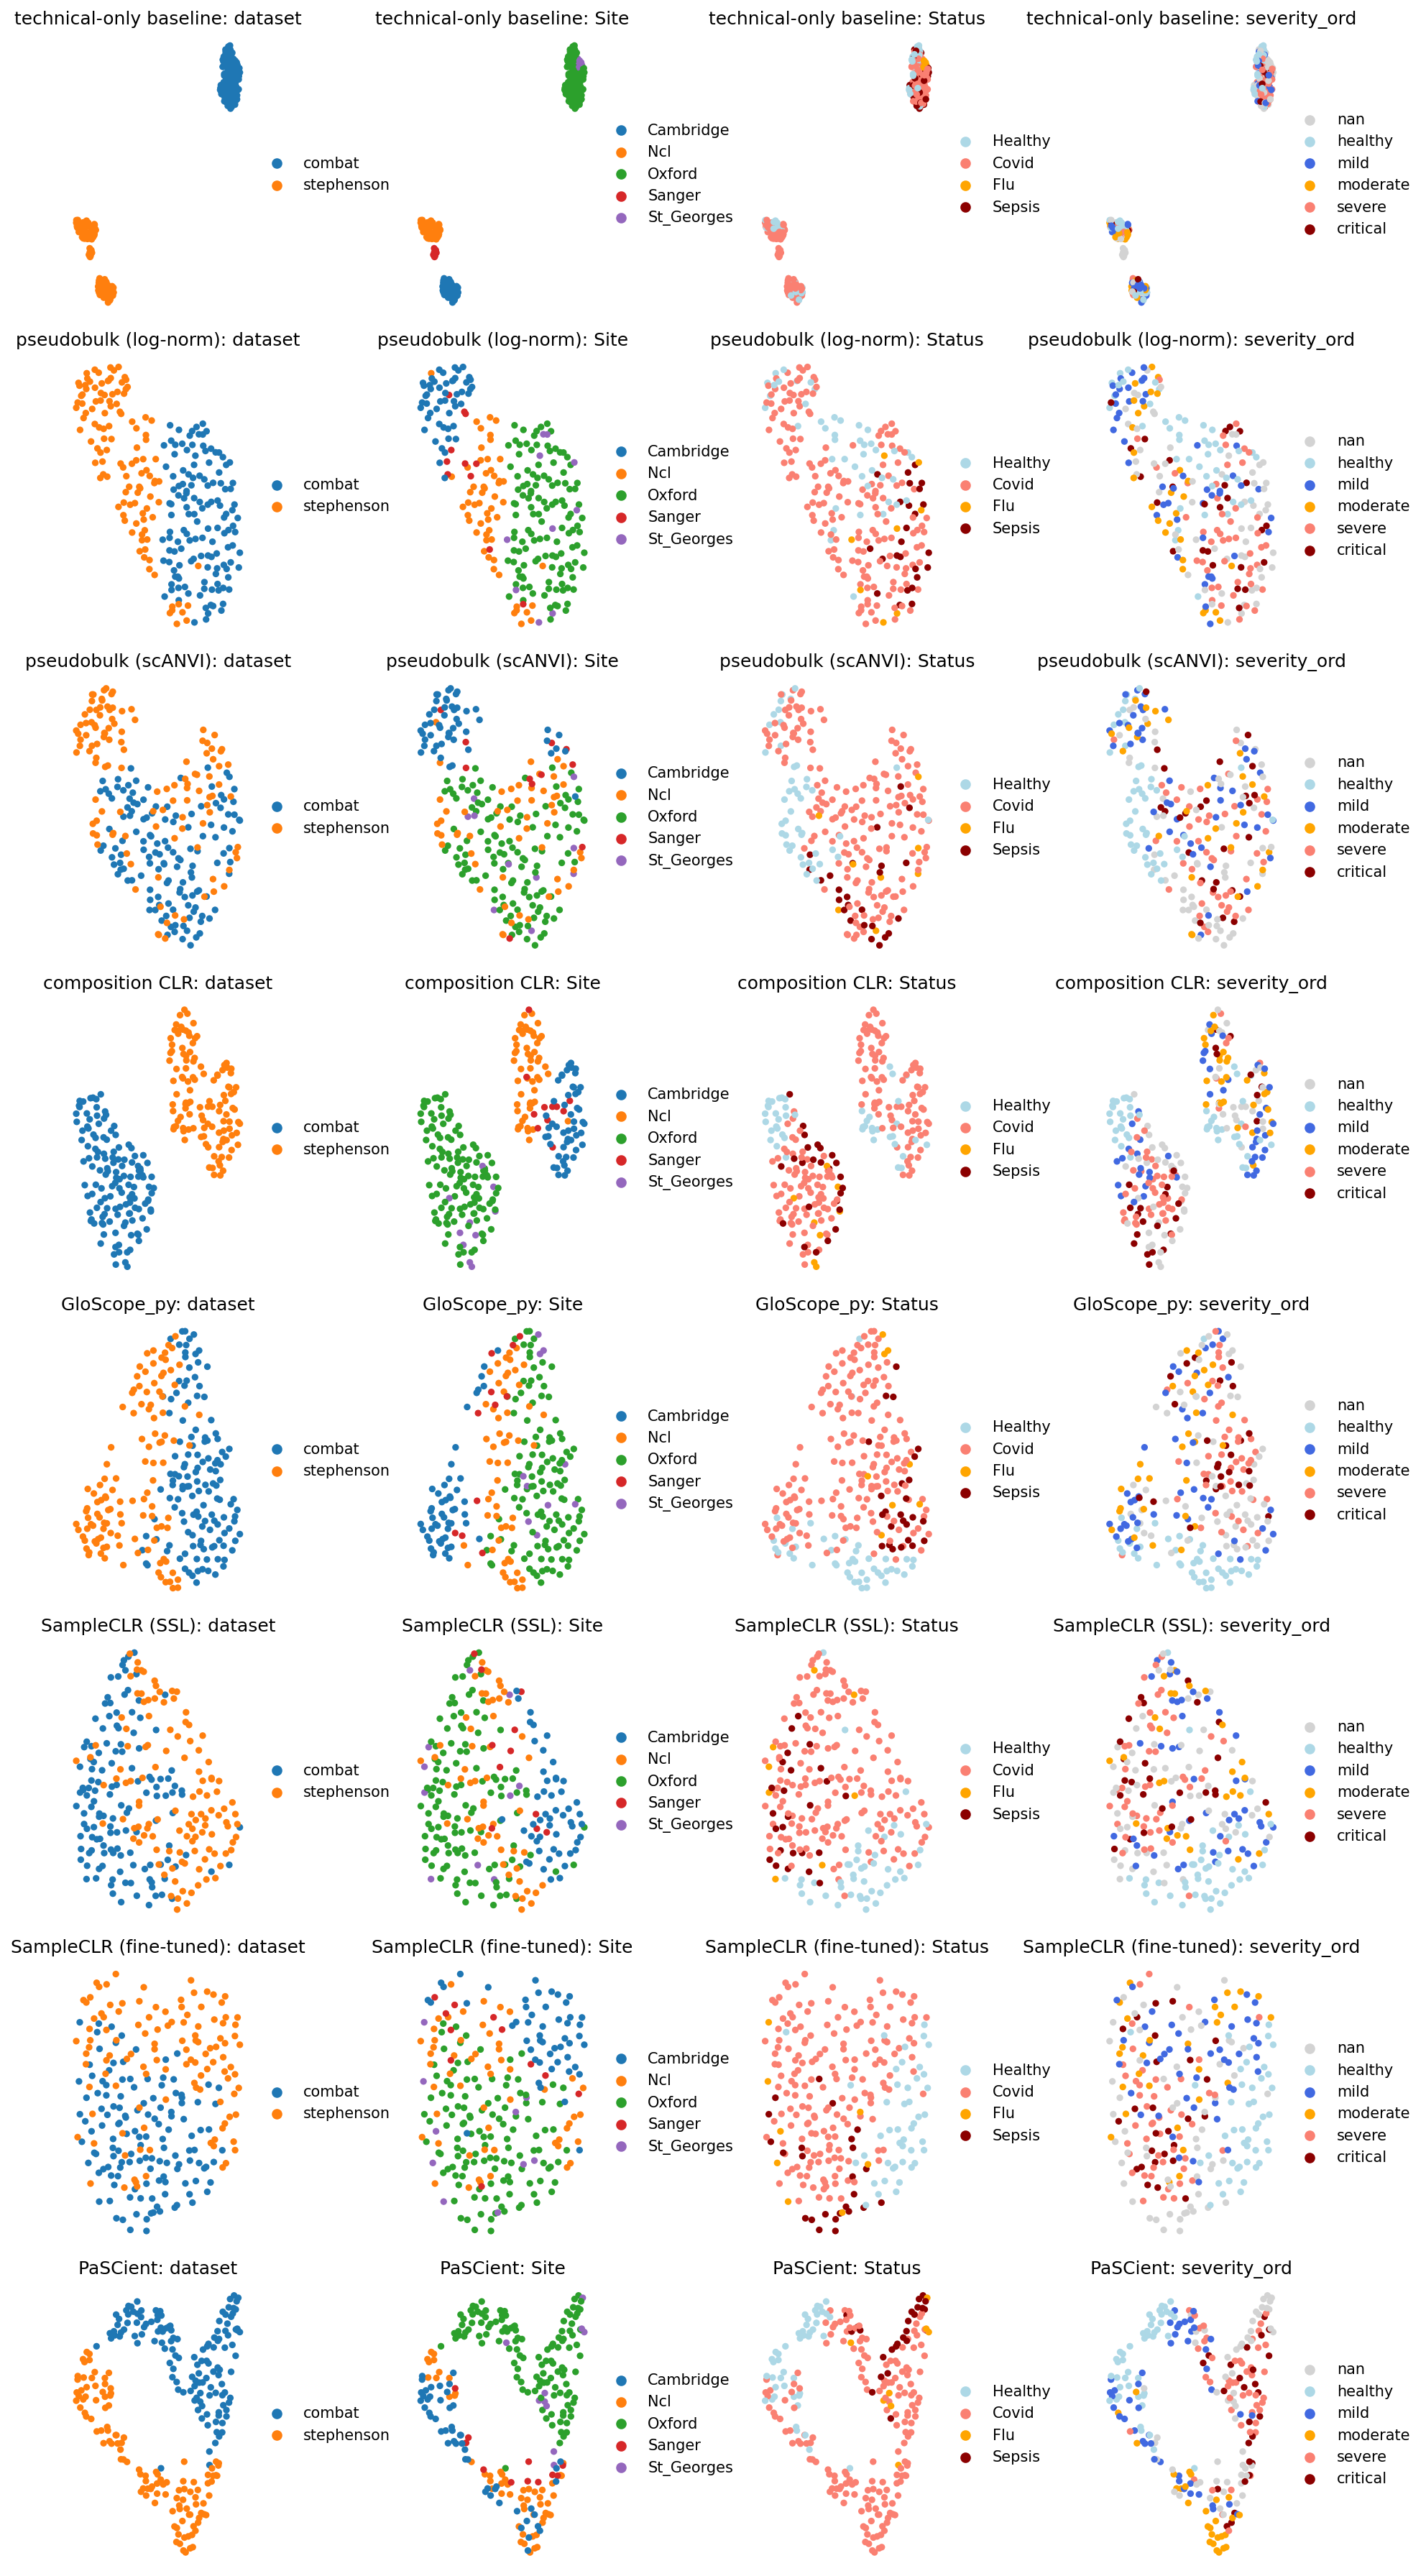

In [27]:
# UMAP grid: 4 covariates per representation (dataset, Site, Status, severity)
PANEL_COVARIATES = ["dataset", "Site", "Status", "severity_ord"]

fig, axes = plt.subplots(len(REPS), len(PANEL_COVARIATES),
                         figsize=(3.2 * len(PANEL_COVARIATES), 3.0 * len(REPS)),
                         squeeze=False)
for row, (rep, title) in enumerate(REPS):
    meta_adata.obsm["X_umap"] = meta_adata.obsm[f"X_umap_{rep}"]
    for col, cov in enumerate(PANEL_COVARIATES):
        sc.pl.umap(meta_adata, color=cov, ax=axes[row, col], show=False,
                   frameon=False, title=f"{title}: {cov}", size=80)
plt.tight_layout()
plt.show()
del meta_adata.obsm["X_umap"]


## 9. KNN benchmark — clinical info retention vs batch mixing

`patpy.tl.evaluation.knn_prediction_score` runs a precomputed-distance KNN per `(representation, covariate)` and returns F1 (classification), Spearman ρ (regression / ranking).

- **relevant** (clinical info retention): `severity_idx`, `Status`, `outcome_bin`, `TimeSinceOnset`.
- **technical** (batch mixing): `Site`, `dataset` — scores reversed so higher = better mixing.

Several columns in `combat_stephenson` are stringified categories (`'12.0'`, `'1.0'`, `'-1'`); we coerce them to `float64` so the underlying `KNeighborsRegressor` can multiply them.


In [28]:
from patpy.tl.evaluation import knn_prediction_score

def coerce_numeric(meta_adata, col):
    if col not in meta_adata.obs.columns:
        return
    s = meta_adata.obs[col]
    if s.dtype == np.float64:
        return
    s = s.astype(str).replace({"nan": np.nan, "NaN": np.nan, "None": np.nan, "<NA>": np.nan})
    meta_adata.obs[col] = pd.to_numeric(s, errors="coerce").astype(np.float64)

for col in ("TimeSinceOnset", "severity_idx", "outcome_bin", "Status_encoded", "ifn_score"):
    coerce_numeric(meta_adata, col)

BENCHMARK_SCHEMA = {
    "relevant": {
        "severity_idx":   "ranking",
        "Status":         "classification",
        "outcome_bin":    "classification",
        "TimeSinceOnset": "regression",
        "ifn_score":      "regression",
    },
    "technical": {
        "Site":    "classification",
        "dataset": "classification",
    },
}

knn_df = knn_prediction_score(
    meta_adata,
    benchmark_schema=BENCHMARK_SCHEMA,
    n_neighbors=5,
    reverse_technical_score=True,
)
knn_df.to_csv(DATA_DIR / "benchmark_knn_scores.csv", index=False)
knn_pivot = knn_df.pivot_table(index="representation",
                               columns=["covariate_type", "covariate"],
                               values="score").round(3)
knn_pivot


covariate_type     relevant                                                    \
covariate            Status TimeSinceOnset ifn_score outcome_bin severity_idx   
representation                                                                  
composition_clr       0.447          0.226     0.258       0.000        0.341   
gloscope_py           0.448          0.448     0.879       0.276        0.573   
pascient              0.594          0.167     0.699       0.174        0.556   
pseudobulk_lognorm    0.288          0.365     0.801       0.001        0.417   
pseudobulk_scanvi     0.355          0.382     0.880       0.006        0.415   
sampleclr_ft          0.424          0.446     0.872       0.066        0.623   
sampleclr_ssl         0.408          0.422     0.859       0.126        0.539   
technical_baseline    0.397          0.118     0.360       0.000        0.318   

covariate_type     technical          
covariate               Site dataset  
representation                        
composition_clr        0.372   0.000  
gloscope_py            0.517   0.056  
pascient               0.389   0.024  
pseudobulk_lognorm     0.498   0.032  
pseudobulk_scanvi      0.659   0.235  
sampleclr_ft           0.688   0.249  
sampleclr_ssl          0.657   0.265  
technical_baseline     0.000   0.000

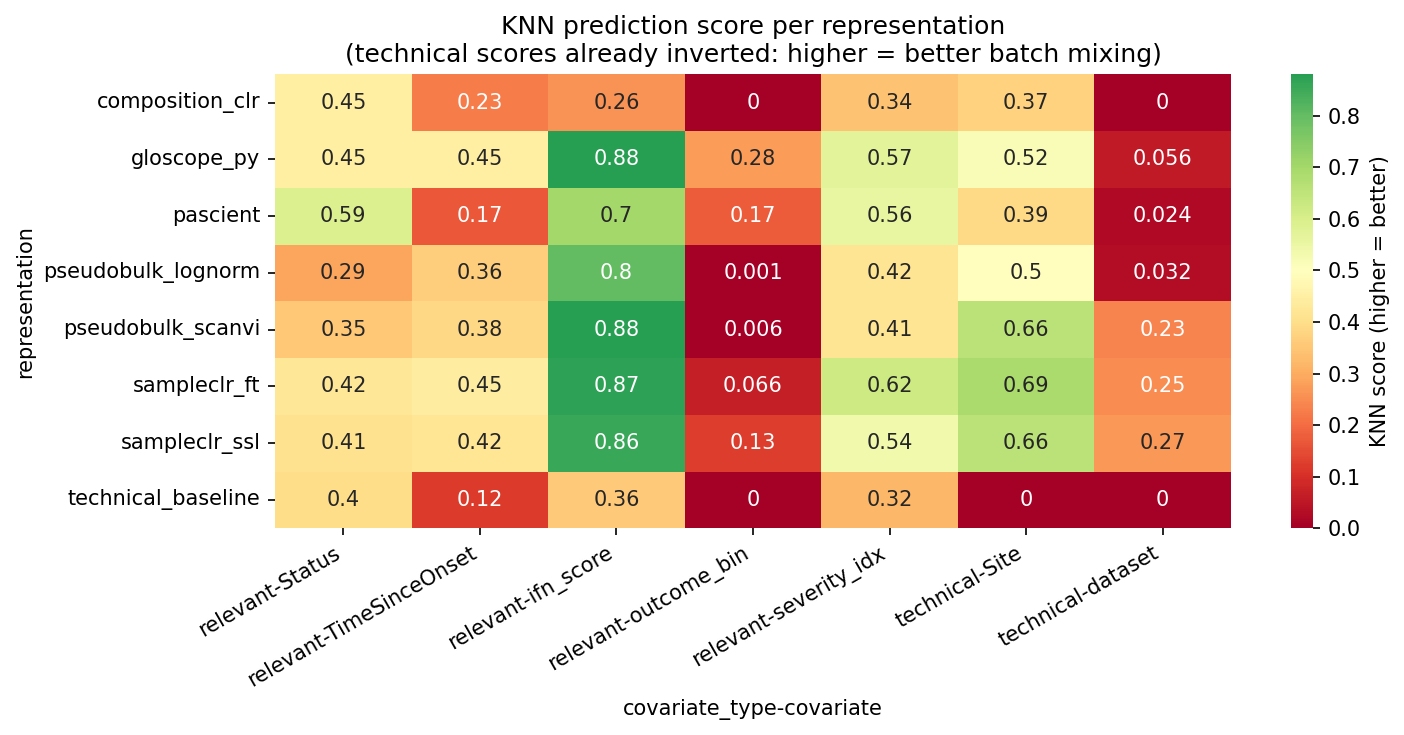

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(knn_pivot, annot=True, cmap="RdYlGn", center=0.5, ax=ax,
            cbar_kws={"label": "KNN score (higher = better)"})
ax.set_title("KNN prediction score per representation\n(technical scores already inverted: higher = better batch mixing)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


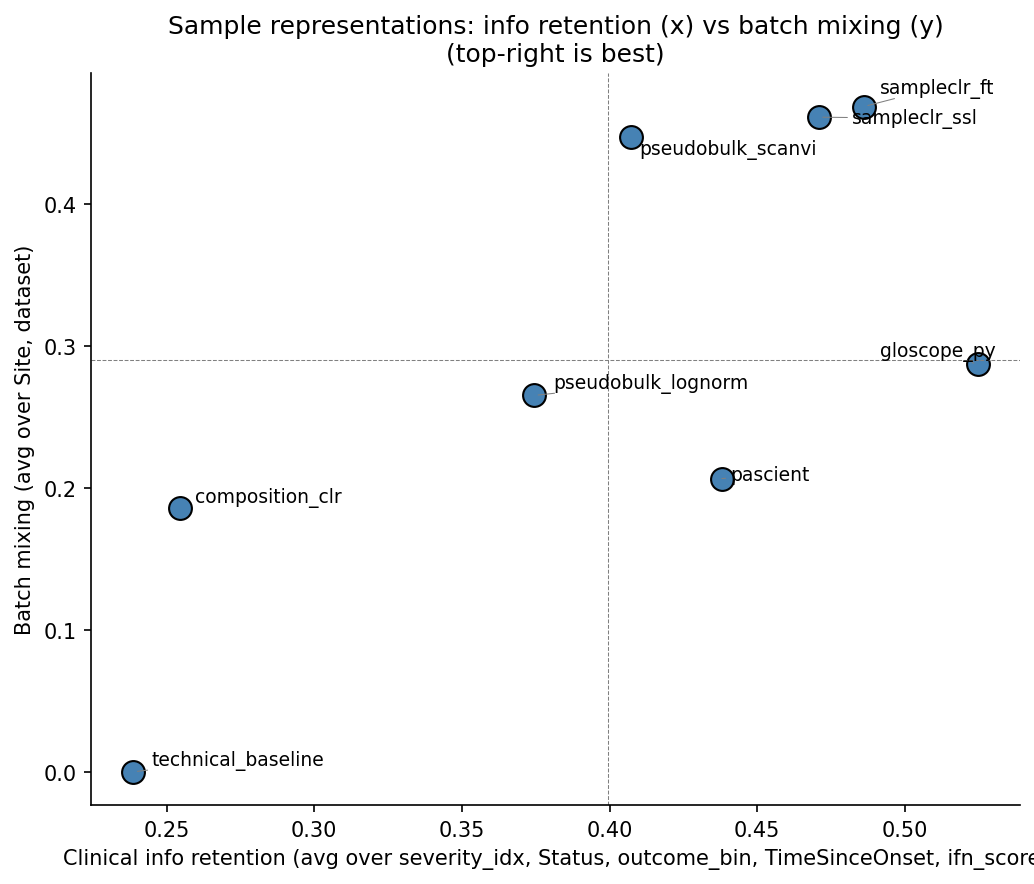

covariate_type,info_retention,batch_mixing
representation,,
gloscope_py,0.525,0.287
sampleclr_ft,0.486,0.468
sampleclr_ssl,0.471,0.461
pascient,0.438,0.207
pseudobulk_scanvi,0.407,0.447
pseudobulk_lognorm,0.374,0.265
composition_clr,0.254,0.186
technical_baseline,0.239,0.000


In [30]:
# Aggregated info-retention vs batch-mixing scatter.
agg = (
    knn_df.groupby(["representation", "covariate_type"])["score"]
    .mean().unstack().rename(columns={"relevant": "info_retention",
                                      "technical": "batch_mixing"})
)
agg.to_csv(DATA_DIR / "benchmark_knn_aggregated.csv")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(agg["info_retention"], agg["batch_mixing"], s=120, color="steelblue", edgecolor="black")
texts = [ax.text(x, y, rep, fontsize=9)
         for rep, (x, y) in agg[["info_retention", "batch_mixing"]].iterrows()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
ax.set_xlabel("Clinical info retention (avg over severity_idx, Status, outcome_bin, TimeSinceOnset, ifn_score)")
ax.set_ylabel("Batch mixing (avg over Site, dataset)")
ax.set_title("Sample representations: info retention (x) vs batch mixing (y)\n(top-right is best)")
ax.axhline(agg["batch_mixing"].mean(),  color="gray", lw=0.5, ls="--")
ax.axvline(agg["info_retention"].mean(), color="gray", lw=0.5, ls="--")
plt.tight_layout()
plt.show()
agg.round(3).sort_values("info_retention", ascending=False)


## 10. Trajectory benchmark — Spearman of pseudotime vs severity

We pin the diffusion-pseudotime root to a specific Healthy donor (`H00049-Ha001E-PBGa` — same as in earlier exploration) so the pseudotime direction is deterministic. `patpy.tl.evaluation.trajectory_correlation` computes diffusion pseudotime per representation and correlates it with `severity_idx`.


trajectory root: H00049-Ha001E-PBGa (Status= Healthy )


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
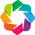

Computing diffmap for technical_baseline
Computing diffmap for pseudobulk_lognorm
Computing diffmap for pseudobulk_scanvi
Computing diffmap for composition_clr
Computing diffmap for gloscope_py
Computing diffmap for sampleclr_ssl
Computing diffmap for sampleclr_ft
Computing diffmap for pascient


,correlation
sampleclr_ft,0.304370
pascient,0.238220
gloscope_py,0.189387
pseudobulk_scanvi,0.142391
sampleclr_ssl,0.117428
pseudobulk_lognorm,-0.069036
composition_clr,-0.097886
technical_baseline,-0.115406


In [31]:
from patpy.tl.evaluation import trajectory_correlation

ROOT_SAMPLE = "H00049-Ha001E-PBGa"
assert ROOT_SAMPLE in meta_adata.obs.index, f"{ROOT_SAMPLE} not in meta_adata.obs"
print("trajectory root:", ROOT_SAMPLE,
      "(Status=", meta_adata.obs.loc[ROOT_SAMPLE, "Status"], ")")

traj_df = trajectory_correlation(
    meta_adata,
    root_sample=ROOT_SAMPLE,
    trajectory_variable="severity_idx",
    force=True,
)
traj_df.to_csv(DATA_DIR / "benchmark_trajectory_correlation.csv")
traj_df


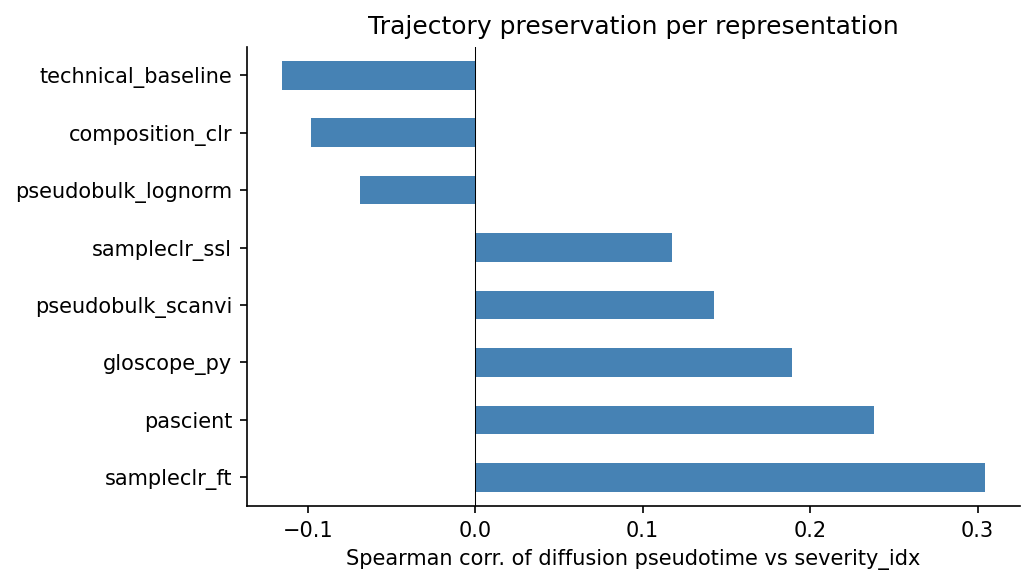

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
traj_df.plot.barh(y="correlation", ax=ax, legend=False, color="steelblue")
ax.set_xlabel("Spearman corr. of diffusion pseudotime vs severity_idx")
ax.set_title("Trajectory preservation per representation")
ax.axvline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()


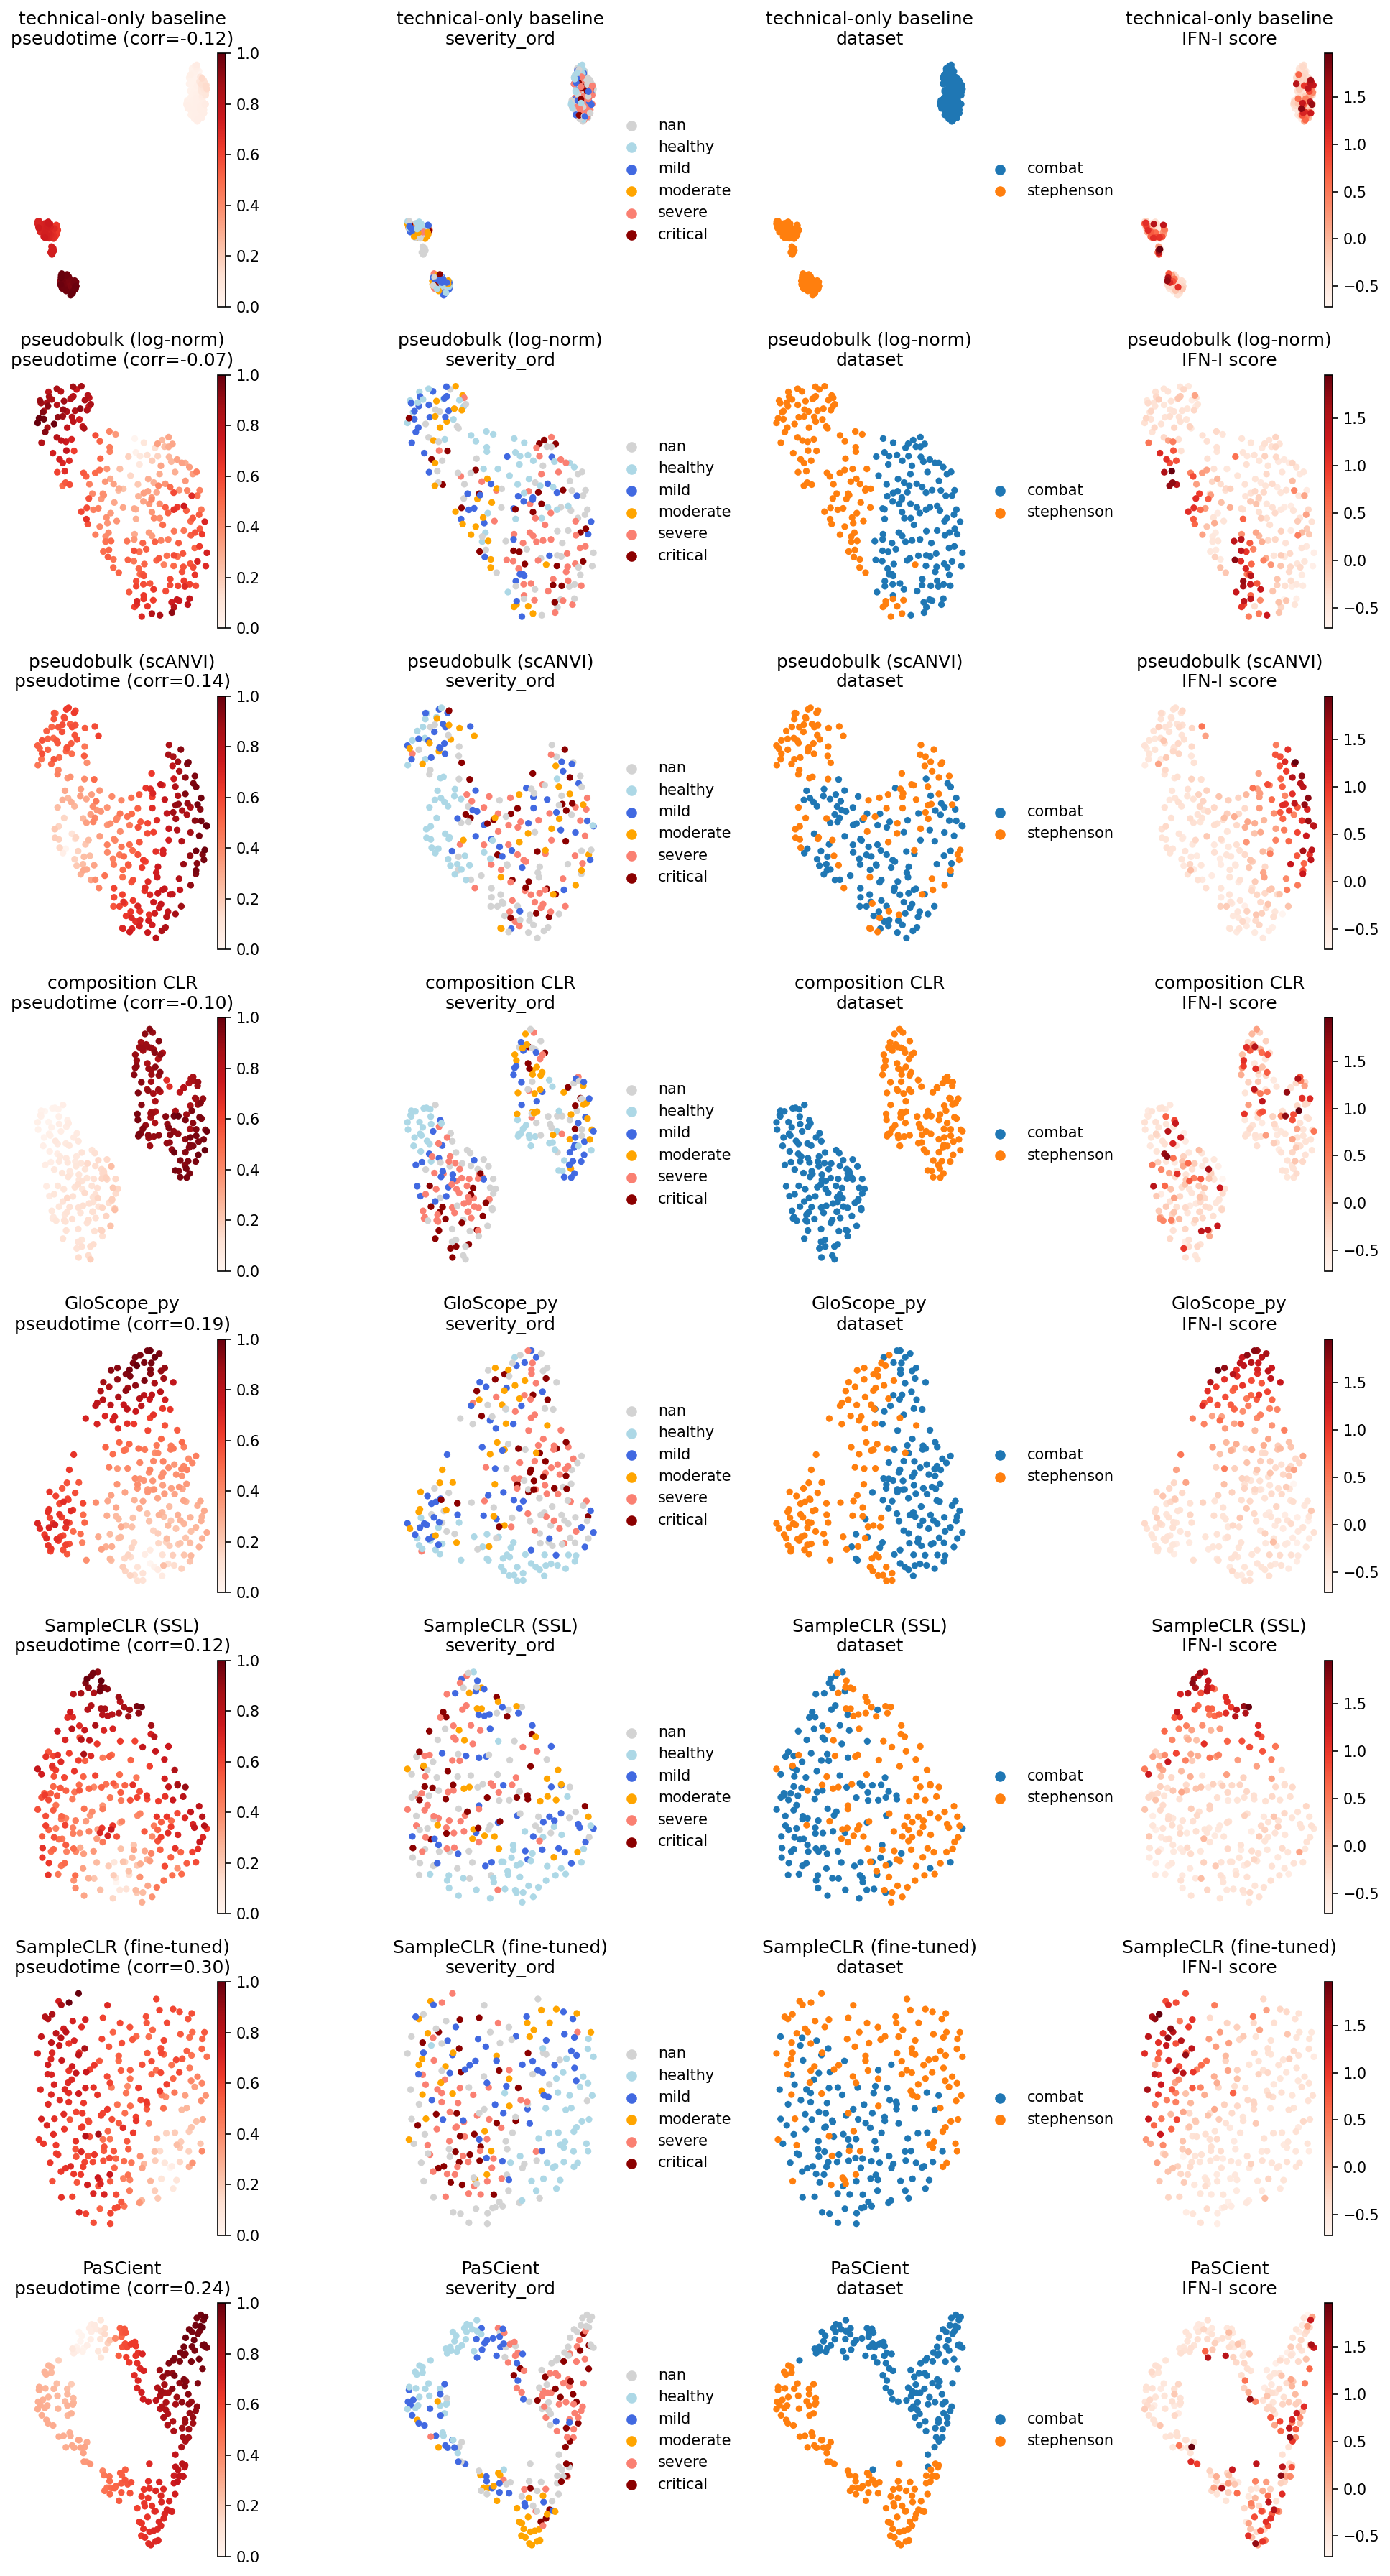

In [33]:
# Per-rep UMAP: pseudotime (Reds) next to severity_ord, dataset, IFN-I score (Reds).
PANEL = ["pseudotime", "severity_ord", "dataset", "ifn_score"]
n = len(REPS); ncols = len(PANEL)
fig, axes = plt.subplots(n, ncols, figsize=(3.2 * ncols, 3.0 * n), squeeze=False)
for i, (rep, title) in enumerate(REPS):
    pt_col = f"{rep}_dpt_pseudotime"
    if pt_col not in meta_adata.obs.columns:
        for ax in axes[i]: ax.set_visible(False)
        continue
    meta_adata.obsm["X_umap"] = meta_adata.obsm[f"X_umap_{rep}"]
    corr = traj_df.loc[rep, "correlation"]
    sc.pl.umap(meta_adata, color=pt_col,         ax=axes[i, 0], show=False, frameon=False, cmap="Reds", size=80, title=f"{title}\npseudotime (corr={corr:.2f})")
    sc.pl.umap(meta_adata, color="severity_ord", ax=axes[i, 1], show=False, frameon=False,              size=80, title=f"{title}\nseverity_ord")
    sc.pl.umap(meta_adata, color="dataset",      ax=axes[i, 2], show=False, frameon=False,              size=80, title=f"{title}\ndataset")
    sc.pl.umap(meta_adata, color="ifn_score",    ax=axes[i, 3], show=False, frameon=False, cmap="Reds", size=80, title=f"{title}\nIFN-I score")
plt.tight_layout(); plt.show()
del meta_adata.obsm["X_umap"]


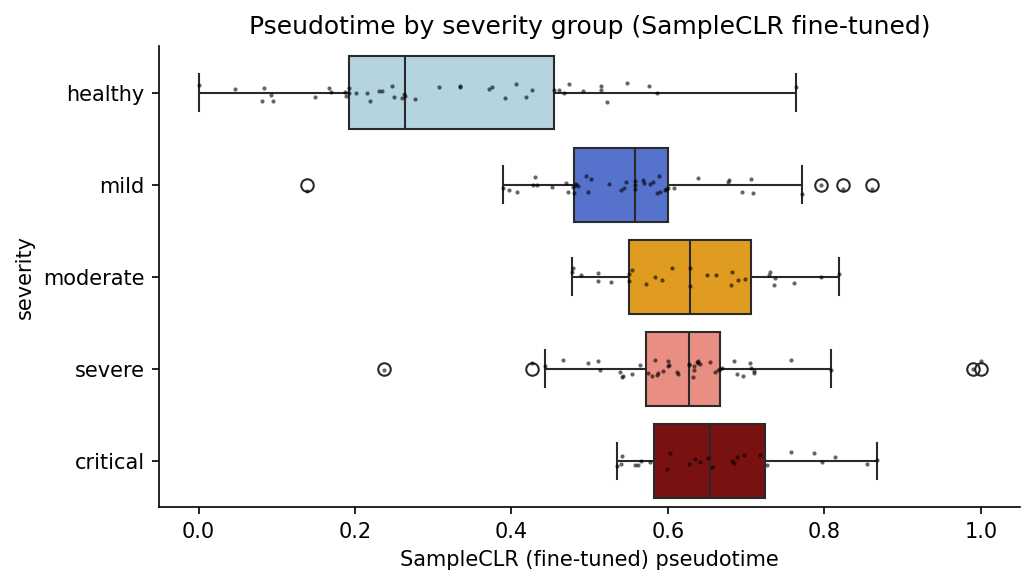

In [34]:
# Sanity-check: pseudotime under SampleCLR (fine-tuned) should increase with
# severity. Drop the "nan" (unknown-severity) donors and colour each box with
# the same severity palette used in the UMAPs.
ft_pt = meta_adata.obs["sampleclr_ft_dpt_pseudotime"].astype(float)
sev = meta_adata.obs["severity_ord"].astype(str)
keep = sev.isin(SEVERITY_ORDER)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(
    x=ft_pt[keep], y=sev[keep], orient="h",
    order=SEVERITY_ORDER, palette=SEVERITY_PALETTE, ax=ax,
)
sns.stripplot(
    x=ft_pt[keep], y=sev[keep], orient="h",
    order=SEVERITY_ORDER, color="black", size=2, alpha=0.6, ax=ax,
)
ax.set_xlabel("SampleCLR (fine-tuned) pseudotime")
ax.set_ylabel("severity")
ax.set_title("Pseudotime by severity group (SampleCLR fine-tuned)")
plt.tight_layout(); plt.show()


## 11. Cluster every representation, ARI vs Site & Status

Running leiden on each rep's neighbor graph gives clusters whose agreement (Adjusted Rand Index) with `Status` measures clinical-signal recovery, while ARI with `Site` measures batch leakage. Higher ARI vs Status = better, lower ARI vs Site = better.


In [35]:
from sklearn.metrics import adjusted_rand_score

ari_rows = []
for rep, _ in REPS:
    nn_key = f"{rep}_neighbors"
    cluster_col = f"{rep}_leiden"
    sc.tl.leiden(meta_adata, neighbors_key=nn_key, resolution=0.5,
                 random_state=SEED, key_added=cluster_col)
    clusters = meta_adata.obs[cluster_col].values
    ari_rows.append({
        "representation": rep,
        "ARI_vs_Status": adjusted_rand_score(meta_adata.obs["Status"].astype(str), clusters),
        "ARI_vs_Site":   adjusted_rand_score(meta_adata.obs["Site"].astype(str), clusters),
        "n_clusters":    int(meta_adata.obs[cluster_col].nunique()),
    })

ari_df = pd.DataFrame(ari_rows).set_index("representation")
ari_df.to_csv(DATA_DIR / "benchmark_clustering_ari.csv")
ari_df.round(3)


,ARI_vs_Status,ARI_vs_Site,n_clusters
representation,,,
technical_baseline,0.035,0.645,6
pseudobulk_lognorm,0.026,0.526,4
pseudobulk_scanvi,0.058,0.216,4
composition_clr,0.075,0.644,4
gloscope_py,0.048,0.237,4
sampleclr_ssl,0.030,0.145,3
sampleclr_ft,0.228,0.158,2
pascient,0.090,0.228,7


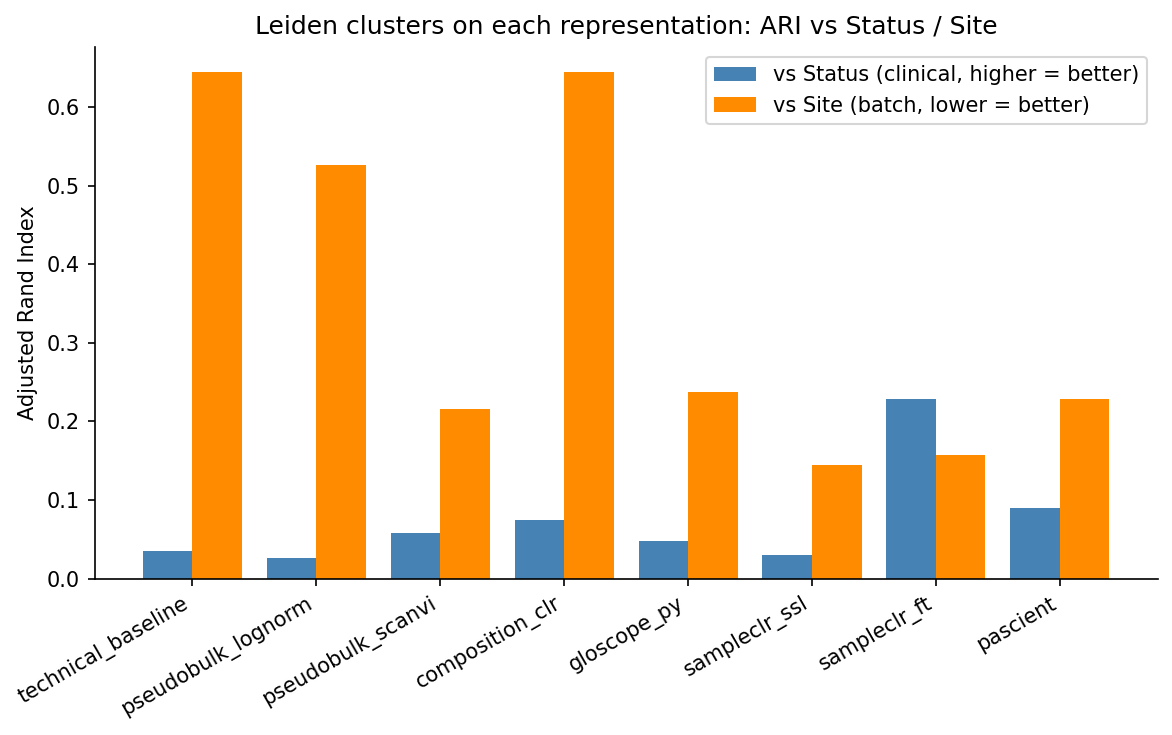

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(ari_df))
w = 0.4
ax.bar(x - w/2, ari_df["ARI_vs_Status"], w,
       label="vs Status (clinical, higher = better)", color="steelblue")
ax.bar(x + w/2, ari_df["ARI_vs_Site"],   w,
       label="vs Site (batch, lower = better)", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(ari_df.index, rotation=30, ha="right")
ax.set_ylabel("Adjusted Rand Index")
ax.set_title("Leiden clusters on each representation: ARI vs Status / Site")
ax.legend()
ax.axhline(0, color="black", lw=0.5)
plt.tight_layout(); plt.show()


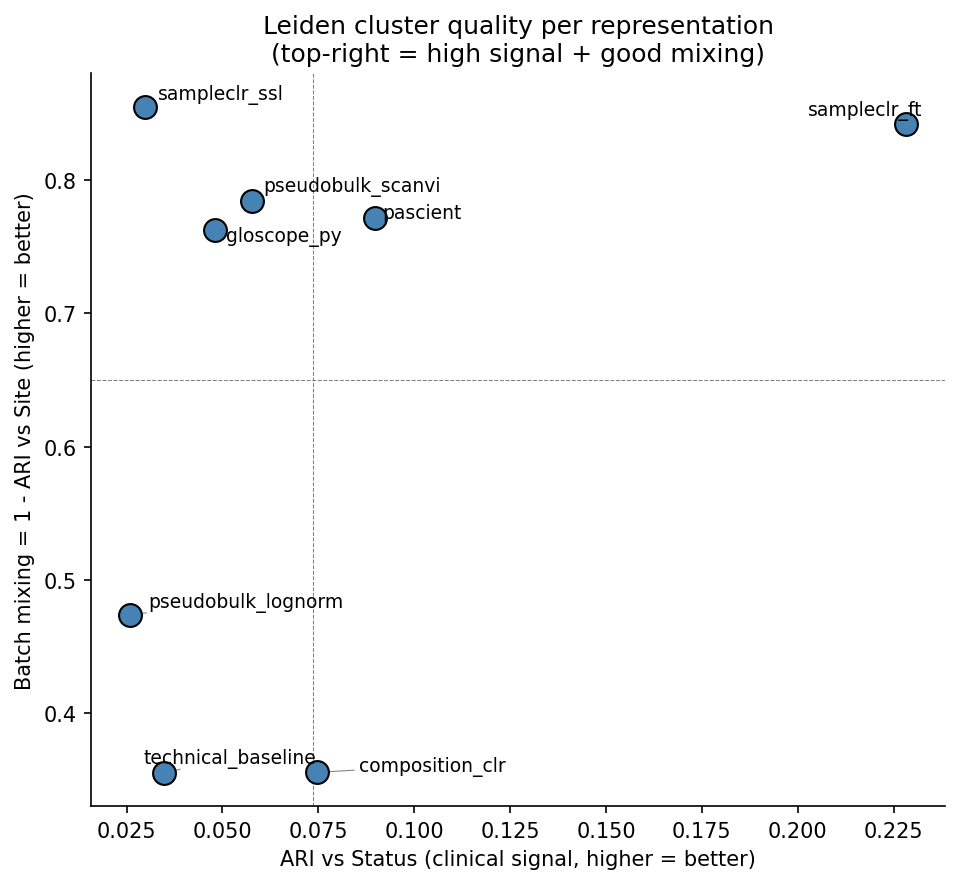

In [37]:
# Scatter view: clinical signal on x, batch mixing on y.
# 'batch_mixing' = 1 - ARI_vs_Site so higher = better (cluster boundaries cut
# across Sites, not along them). Top-right is best on both axes.
batch_mixing = 1 - ari_df["ARI_vs_Site"]

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(ari_df["ARI_vs_Status"], batch_mixing,
           s=120, color="steelblue", edgecolor="black", zorder=3)
texts = []
for rep, xv in ari_df["ARI_vs_Status"].items():
    yv = batch_mixing.loc[rep]
    texts.append(ax.text(xv, yv, rep, fontsize=9))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
ax.set_xlabel("ARI vs Status (clinical signal, higher = better)")
ax.set_ylabel("Batch mixing = 1 - ARI vs Site (higher = better)")
ax.set_title("Leiden cluster quality per representation\n(top-right = high signal + good mixing)")
ax.axhline(batch_mixing.mean(),             color="gray", lw=0.5, ls="--")
ax.axvline(ari_df["ARI_vs_Status"].mean(),  color="gray", lw=0.5, ls="--")
plt.tight_layout(); plt.show()


## 12. For the best trajectory rep: gene + cell-type-proportion correlation with pseudotime

We pick whichever representation tops the trajectory benchmark. Per donor we have a pseudotime; we lift it to per-cell (every cell of donor *d* gets *d*'s pseudotime), then Spearman-correlate every gene's log-norm expression with pseudotime. Cell-type proportions are correlated at the donor level.


In [38]:
from scipy import stats as scstats
from scipy.sparse import issparse

best_rep = traj_df.index[0]
best_pt_col = f"{best_rep}_dpt_pseudotime"
print(f"best trajectory representation: {best_rep}  (corr={traj_df.iloc[0, 0]:.3f})")

# Cell-type proportions per donor (raw, not CLR) → correlate each cell type with pseudotime
ct_props = pd.crosstab(adata.obs[info.sample_key], adata.obs[info.cell_type_key], normalize="index")
ct_props = ct_props.reindex(meta_adata.obs.index)
pt_per_donor = meta_adata.obs[best_pt_col].astype(float)

ct_corr_rows = []
for ct in ct_props.columns:
    rho, p = scstats.spearmanr(ct_props[ct].values, pt_per_donor.values, nan_policy="omit")
    ct_corr_rows.append({"cell_type": ct, "spearman_r": rho, "p": p})
ct_corr = pd.DataFrame(ct_corr_rows).sort_values("spearman_r", ascending=False)
ct_corr.to_csv(DATA_DIR / f"pseudotime_celltype_correlation_{best_rep}.csv", index=False)
ct_corr.round(3)


best trajectory representation: sampleclr_ft  (corr=0.304)


,cell_type,spearman_r,p
13,Plasmablast,0.369,0.000
15,cMono,0.240,0.000
7,HSC,0.228,0.000
12,PLT,0.151,0.017
0,B,0.103,0.104
14,RET,0.096,0.128
8,Lymph_prolif,0.096,0.129
4,DN,-0.084,0.182
11,NK,-0.095,0.133
17,ncMono,-0.098,0.120


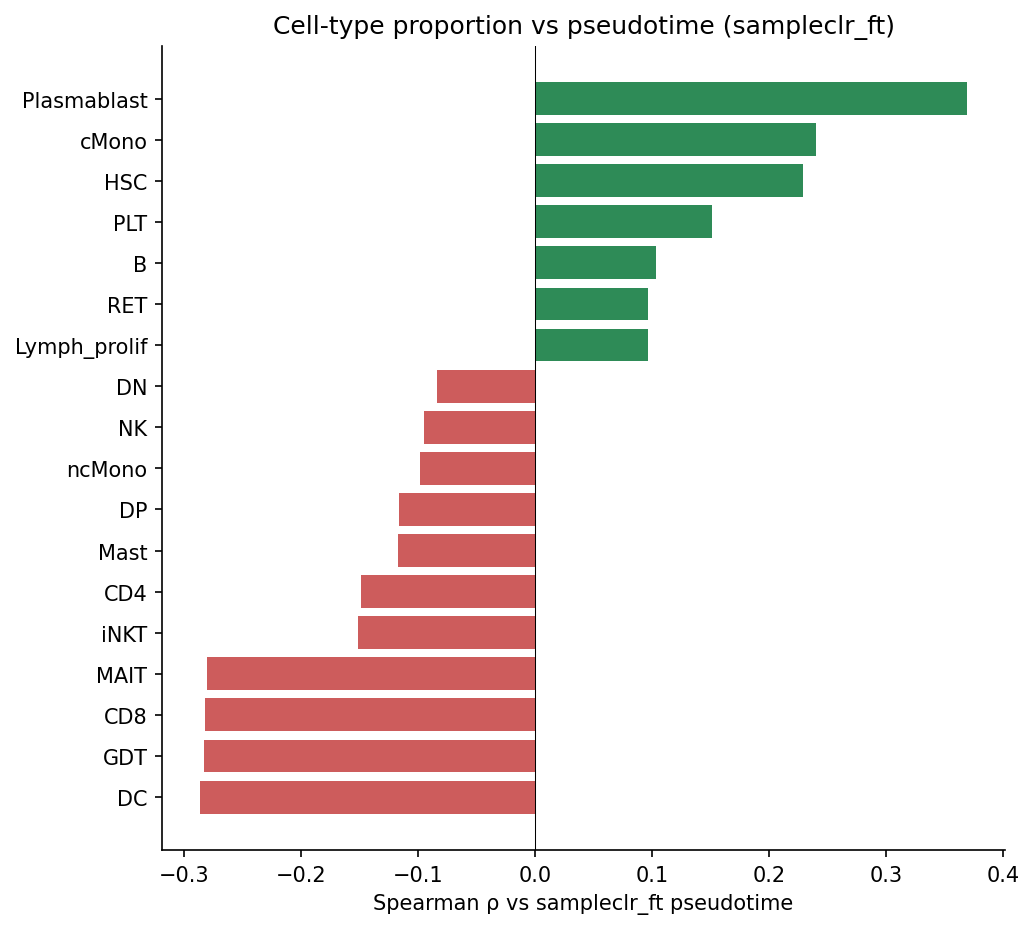

In [39]:
fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * len(ct_corr))))
ct_plot = ct_corr.set_index("cell_type")["spearman_r"].sort_values()
colors = ["indianred" if v < 0 else "seagreen" for v in ct_plot.values]
ax.barh(ct_plot.index, ct_plot.values, color=colors)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel(f"Spearman ρ vs {best_rep} pseudotime")
ax.set_title(f"Cell-type proportion vs pseudotime ({best_rep})")
plt.tight_layout(); plt.show()


In [40]:
# Gene correlation with pseudotime: lift donor-level pseudotime to per-cell, then
# Spearman-correlate each gene. We vectorise via Pearson on rank-transformed
# pseudotime (equivalent to Spearman) and chunk over genes.
pt_per_cell = adata.obs[info.sample_key].map(pt_per_donor.to_dict()).astype(float).values
keep = ~np.isnan(pt_per_cell)
pt_kept = pt_per_cell[keep]
pt_rank = scstats.rankdata(pt_kept).astype(np.float32)
pt_rank -= pt_rank.mean(); pt_rank /= pt_rank.std()

X = adata.layers[LOGNORM_LAYER][keep]
n_cells = X.shape[0]
corrs = np.zeros(adata.n_vars, dtype=np.float32)
chunk = 500
for s in range(0, adata.n_vars, chunk):
    e = min(s + chunk, adata.n_vars)
    Xs = X[:, s:e]
    if issparse(Xs):
        Xs = Xs.toarray()
    Xs = Xs.astype(np.float32)
    Xs_rank = np.empty_like(Xs)
    for j in range(Xs.shape[1]):
        Xs_rank[:, j] = scstats.rankdata(Xs[:, j])
    Xs_rank -= Xs_rank.mean(axis=0)
    std = Xs_rank.std(axis=0); std[std == 0] = 1
    Xs_rank /= std
    corrs[s:e] = (Xs_rank * pt_rank[:, None]).sum(axis=0) / n_cells

gene_corr = pd.DataFrame({
    "ensembl_id": adata.var["ensembl_id"].values,
    "gene_name":  adata.var["gene_name"].values,
    "spearman_r": corrs,
})
gene_corr.to_csv(DATA_DIR / f"pseudotime_gene_correlation_{best_rep}.csv", index=False)
top_pos = gene_corr.nlargest(15, "spearman_r")
top_neg = gene_corr.nsmallest(15, "spearman_r")
print("Top + correlated genes:"); print(top_pos[["gene_name", "spearman_r"]].to_string(index=False))
print("\nTop − correlated genes:"); print(top_neg[["gene_name", "spearman_r"]].to_string(index=False))


Top + correlated genes:
gene_name  spearman_r
   IFI44L    0.402109
     IFI6    0.352407
    ISG15    0.315677
      MX1    0.303018
    IFIT3    0.280911
    IFI27    0.272089
     IRF7    0.259341
    RSAD2    0.231900
   EPSTI1    0.231825
     OAS1    0.227041
    IFIT1    0.224087
   PLSCR1    0.210263
   IFITM3    0.190231
      CLU    0.188914
    CMPK2    0.183654

Top − correlated genes:
gene_name  spearman_r
   MT-CYB   -0.266437
    ACTG1   -0.175349
     ACTB   -0.154939
     NPM1   -0.122109
     IL32   -0.112992
     IL7R   -0.105851
     TUBB   -0.095161
     CD27   -0.094999
   S100A4   -0.089448
     GZMK   -0.088762
     FTH1   -0.084948
      VIM   -0.083811
  SLC25A5   -0.081960
    HMGB1   -0.081159
     CD8B   -0.078018


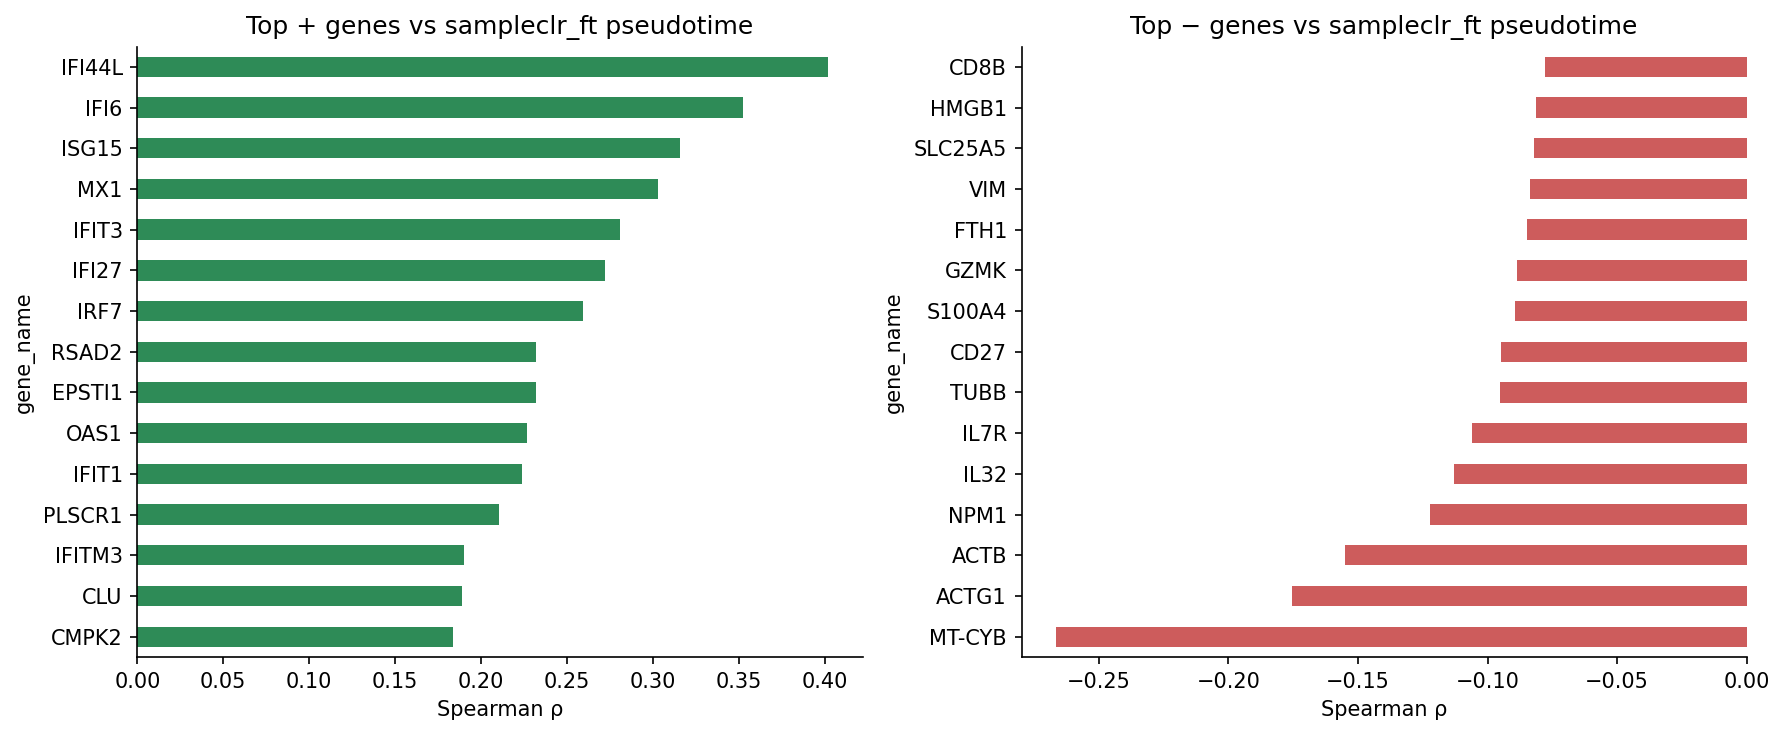

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_pos.set_index("gene_name")["spearman_r"].sort_values().plot.barh(ax=axes[0], color="seagreen")
axes[0].set_title(f"Top + genes vs {best_rep} pseudotime")
axes[0].set_xlabel("Spearman ρ")
top_neg.set_index("gene_name")["spearman_r"].sort_values().plot.barh(ax=axes[1], color="indianred")
axes[1].set_title(f"Top − genes vs {best_rep} pseudotime")
axes[1].set_xlabel("Spearman ρ")
plt.tight_layout(); plt.show()


## 13. Marker genes for SampleCLR (fine-tuned) clusters

Lift each donor's `sampleclr_ft_leiden` cluster down to its cells, then run `sc.tl.rank_genes_groups` on the cell-level adata. Each cluster's top markers tell us what makes those donors transcriptionally distinct in the supervised representation.


In [42]:
sclr_ft_clusters = meta_adata.obs["sampleclr_ft_leiden"]
adata.obs["sampleclr_ft_cluster"] = (
    adata.obs[info.sample_key].map(sclr_ft_clusters).astype("category")
)
print(adata.obs["sampleclr_ft_cluster"].value_counts())

# rank_genes_groups stores whatever sits in adata.var_names. Swap them to gene
# symbols (already resolved in section 2b) so the plot/table are readable. Use
# make_unique to suppress duplicate-symbol collisions.
adata.var_names = pd.Index(adata.var["gene_name"]).astype(str)
adata.var_names_make_unique()

sc.tl.rank_genes_groups(
    adata, groupby="sampleclr_ft_cluster",
    method="wilcoxon", layer=LOGNORM_LAYER, n_genes=25,
)


sampleclr_ft_cluster
0    1002799
1     396636
Name: count, dtype: int64


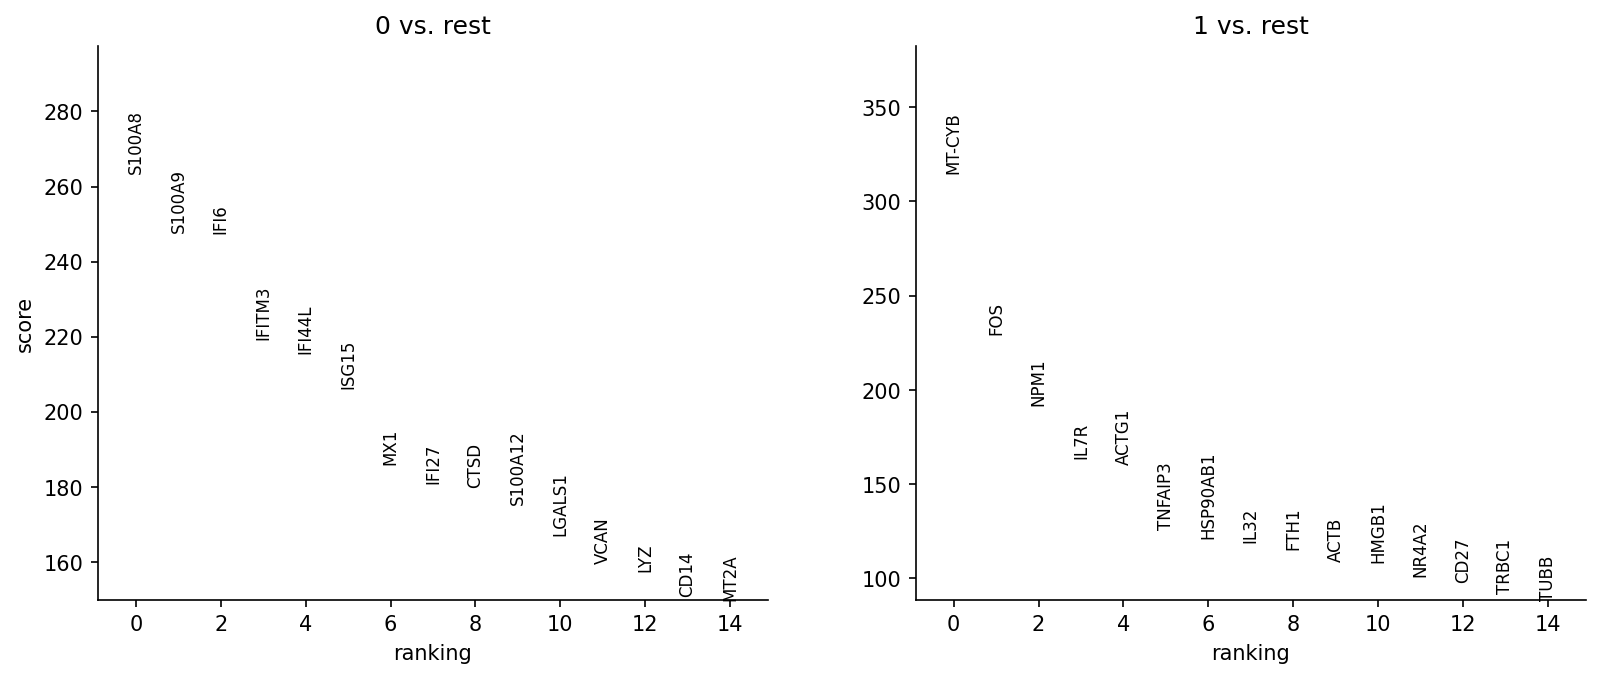

In [43]:
sc.pl.rank_genes_groups(adata, n_genes=15, sharey=False)


In [44]:
# Top-5 markers per cluster, with both symbol and Ensembl ID for traceability.
symbol_to_ensembl = dict(zip(adata.var_names, adata.var["ensembl_id"]))
markers_records = []
groups = adata.uns["rank_genes_groups"]["names"].dtype.names
for g in groups:
    for i in range(5):
        symbol = adata.uns["rank_genes_groups"]["names"][g][i]
        markers_records.append({
            "cluster": g,
            "rank": i + 1,
            "gene_symbol": symbol,
            "ensembl_id": symbol_to_ensembl.get(symbol, ""),
            "logfc":     float(adata.uns["rank_genes_groups"]["logfoldchanges"][g][i]),
            "pval_adj":  float(adata.uns["rank_genes_groups"]["pvals_adj"][g][i]),
        })
markers_df = pd.DataFrame(markers_records)
markers_df.to_csv(DATA_DIR / "sampleclr_ft_cluster_markers.csv", index=False)
markers_df.head(25)


,cluster,rank,gene_symbol,ensembl_id,logfc,pval_adj
0,0,1,S100A8,ENSG00000143546,2.302234,0.0
1,0,2,S100A9,ENSG00000163220,2.130208,0.0
2,0,3,IFI6,ENSG00000126709,1.999037,0.0
3,0,4,IFITM3,ENSG00000142089,1.516453,0.0
4,0,5,IFI44L,ENSG00000137959,2.952466,0.0
5,1,1,MT-CYB,ENSG00000198727,1.158953,0.0
6,1,2,FOS,ENSG00000170345,1.214242,0.0
7,1,3,NPM1,ENSG00000181163,1.071146,0.0
8,1,4,IL7R,ENSG00000168685,1.432887,0.0
9,1,5,ACTG1,ENSG00000184009,0.534403,0.0


## 14. Persist the final `meta_adata`


In [45]:
META_ADATA_FINAL = DATA_DIR / "stephenson_combat_meta_adata.h5ad"
np.savez(DATA_DIR / "gloscope_py_distances.npz",
         distances=distances_gloscope, samples=np.asarray(gs.samples))

meta_adata.write_h5ad(META_ADATA_FINAL)
print("final meta_adata:", META_ADATA_FINAL)
print("  obsm keys :", sorted(meta_adata.obsm.keys()))
print("  uns reps  :", meta_adata.uns.get("sample_representations"))
print("  benchmarks:",
      "benchmark_knn_scores.csv,",
      "benchmark_knn_aggregated.csv,",
      "benchmark_trajectory_correlation.csv,",
      "benchmark_clustering_ari.csv,",
      f"pseudotime_celltype_correlation_{best_rep}.csv,",
      f"pseudotime_gene_correlation_{best_rep}.csv,",
      "sampleclr_ft_cluster_markers.csv")
print("  models    :", *(p.name for p in [
    MODELS_DIR / "sampleclr_ssl_state.pt",
    MODELS_DIR / "sampleclr_ft_state.pt",
    MODELS_DIR / "pascient_state.pt",
]))


final meta_adata: /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/docs/notebooks/data/stephenson_combat/stephenson_combat_meta_adata.h5ad
  obsm keys : ['X_composition_clr', 'X_composition_clr_diffmap', 'X_diffmap', 'X_gloscope_py', 'X_gloscope_py_diffmap', 'X_pascient', 'X_pascient_diffmap', 'X_pseudobulk_lognorm', 'X_pseudobulk_lognorm_diffmap', 'X_pseudobulk_scanvi', 'X_pseudobulk_scanvi_diffmap', 'X_sampleclr_ft', 'X_sampleclr_ft_diffmap', 'X_sampleclr_ssl', 'X_sampleclr_ssl_diffmap', 'X_technical_baseline', 'X_technical_baseline_diffmap', 'X_umap_composition_clr', 'X_umap_gloscope_py', 'X_umap_pascient', 'X_umap_pseudobulk_lognorm', 'X_umap_pseudobulk_scanvi', 'X_umap_sampleclr_ft', 'X_umap_sampleclr_ssl', 'X_umap_technical_baseline', 'composition_clr', 'composition_clr_distances', 'gloscope_py', 'gloscope_py_distances', 'pascient', 'pascient_distances', 'pseudobulk_lognorm', 'pseudobulk_lognorm_distances', 'pseudobulk_scanvi', 'pseudobulk_scanvi_distances', 'sampleclr_f